In [42]:
!pip install -q open_clip_torch factor_analyzer semopy

In [43]:
import os
import json
import math
import random
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import open_clip
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo: cuda
GPU: Tesla T4


In [44]:
RUTA_DATASET = Path("/kaggle/input/datasets/edwardsx/tiles-rescate-1500")
RUTA_SALIDA = Path("/kaggle/working/geovision_clip_sit2")
RUTA_SALIDA.mkdir(parents=True, exist_ok=True)

TILE_SIZE = 64
CHANNELS_S2 = 13
CONTRASTIVE_DIM = 256
SAE_DICT_DIM = 512
TEMP_INIT = 0.07

BATCH_SIZE = 32
EPOCHS = 30
GRAD_ACCUM = 2
LEARNING_RATE = 8e-5
WEIGHT_DECAY = 5e-4
ALPHA_SAE = 0.07
SAE_L1_REG = 1e-3
AUX_CLS_WEIGHT = 0.40
LABEL_SMOOTHING = 0.05
TRAIN_LAST_BLOCKS = 2
TABULAR_DROPOUT = 0.30
SAE_HIDDEN_VISUAL = 2048
SAE_HIDDEN_TEXT = 1024
SAE_SPARSE_DIM = 256

SAE_DEAD_THRESHOLD = 1e-3
SPARSITY_KPI_THRESH = 0.01
NUM_WORKERS = 0

print("Configuración lista")
print(f"Salida: {RUTA_SALIDA}")

Configuración lista
Salida: /kaggle/working/geovision_clip_sit2


In [45]:
meta_df = pd.read_parquet(RUTA_DATASET / "tiles_meta.parquet")

with np.load(RUTA_DATASET / "tiles_train.npz") as data:
    images_raw = data["data"]
    bands = list(data["bands"])

print(f"Metadata: {meta_df.shape}")
print(f"Imágenes: {images_raw.shape}")
print(f"Bandas: {bands}")

Metadata: (1500, 22)
Imágenes: (1500, 13, 64, 64)
Bandas: [np.str_('B1'), np.str_('B2'), np.str_('B3'), np.str_('B4'), np.str_('B5'), np.str_('B6'), np.str_('B7'), np.str_('B8'), np.str_('B8A'), np.str_('B9'), np.str_('B11'), np.str_('B12'), np.str_('SCL')]


In [47]:
CLASES_ORDENADAS = [
    "contaminacion_alta_NO2",
    "contaminacion_alta_SO2",
    "ozono_anomalo",
    "suelo_urbano",
    "vegetacion_densa",
]

conteo_clases = meta_df["clase"].value_counts().reindex(CLASES_ORDENADAS)
print("Conteo por clase")
print(conteo_clases)

assert images_raw.shape == (1500, 13, 64, 64), "Forma inesperada en tiles_train.npz"
assert meta_df.shape[0] == images_raw.shape[0], "Metadata e imágenes no coinciden"
assert set(meta_df["clase"].unique()) == set(CLASES_ORDENADAS), "Clases inesperadas"
assert bands == ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B9", "B11", "B12", "SCL"], "Bandas inesperadas"

print("Auditoría estructural superada")

Conteo por clase
clase
contaminacion_alta_NO2    300
contaminacion_alta_SO2    300
ozono_anomalo             300
suelo_urbano              300
vegetacion_densa          300
Name: count, dtype: int64
Auditoría estructural superada


In [48]:
cols_auditoria = ["ndvi", "ndbi", "scl_pct", "no2", "so2", "o3", "modis_AOD_047", "modis_AOD_055", "modis_WV"]
cols_auditoria = [c for c in cols_auditoria if c in meta_df.columns]

resumen_clase = meta_df.groupby("clase")[["ndvi", "ndbi", "scl_pct"]].agg(["mean", "min", "max"]).round(4)
display(resumen_clase)

nulos = meta_df[cols_auditoria].isna().mean().sort_values(ascending=False).mul(100).round(2)
print("Nulos porcentuales")
print(nulos[nulos > 0])

ndvi                    ndbi                  \
                          mean     min     max    mean     min     max   
clase                                                                    
contaminacion_alta_NO2  0.3319  0.1829  0.4716  0.0264 -0.0998  0.1132   
contaminacion_alta_SO2  0.5297  0.3487  0.6498 -0.0984 -0.2183  0.0573   
ozono_anomalo           0.4844  0.2872  0.5999 -0.0624 -0.2944  0.0968   
suelo_urbano            0.1470  0.0259  0.2090  0.1410  0.0785  0.1968   
vegetacion_densa        0.7386  0.6674  0.8389 -0.2955 -0.3902 -0.2205   

                       scl_pct               
                          mean     min  max  
clase                                        
contaminacion_alta_NO2  0.9982  0.9619  1.0  
contaminacion_alta_SO2  0.9950  0.9258  1.0  
ozono_anomalo           0.9941  0.9121  1.0  
suelo_urbano            0.9988  0.9771  1.0  
vegetacion_densa        0.9996  0.9893  1.0

Nulos porcentuales
modis_AOD_055    82.13
modis_AOD_047    82.13
o3               80.00
so2              80.00
no2              80.00
modis_WV          2.27
dtype: float64


In [49]:
urbano = meta_df[meta_df["clase"] == "suelo_urbano"]
vegetacion = meta_df[meta_df["clase"] == "vegetacion_densa"]

print("Chequeo suelo urbano corregido")
print(f"NDVI urbano medio: {urbano['ndvi'].mean():.4f}")
print(f"NDBI urbano medio: {urbano['ndbi'].mean():.4f}")
print(f"NDVI vegetación medio: {vegetacion['ndvi'].mean():.4f}")
print(f"NDBI vegetación medio: {vegetacion['ndbi'].mean():.4f}")

assert urbano["ndvi"].mean() < 0.30, "Suelo urbano no parece suficientemente estricto por NDVI"
assert urbano["ndbi"].mean() > 0.05, "Suelo urbano no parece suficientemente estricto por NDBI"
assert vegetacion["ndvi"].mean() > 0.60, "Vegetación densa no parece suficientemente verde"

print("Auditoría óptica superada")

Chequeo suelo urbano corregido
NDVI urbano medio: 0.1470
NDBI urbano medio: 0.1410
NDVI vegetación medio: 0.7386
NDBI vegetación medio: -0.2955
Auditoría óptica superada


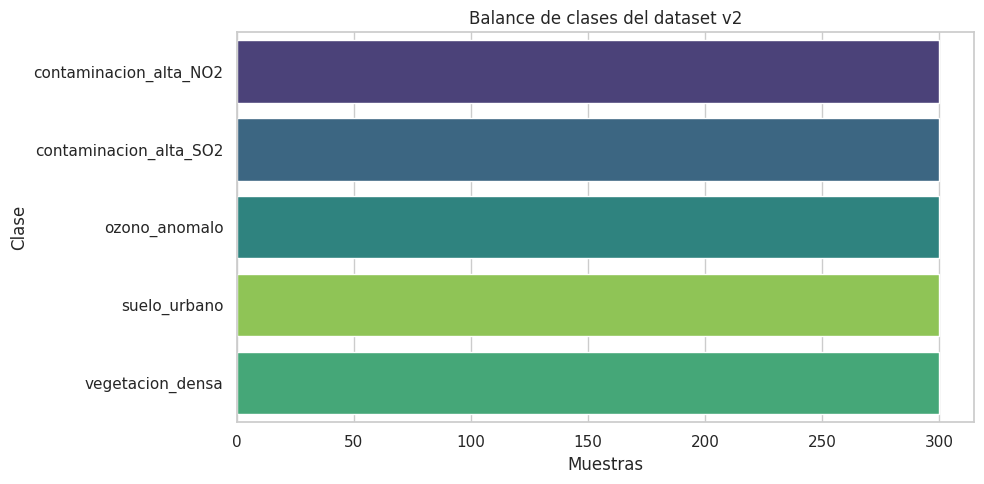

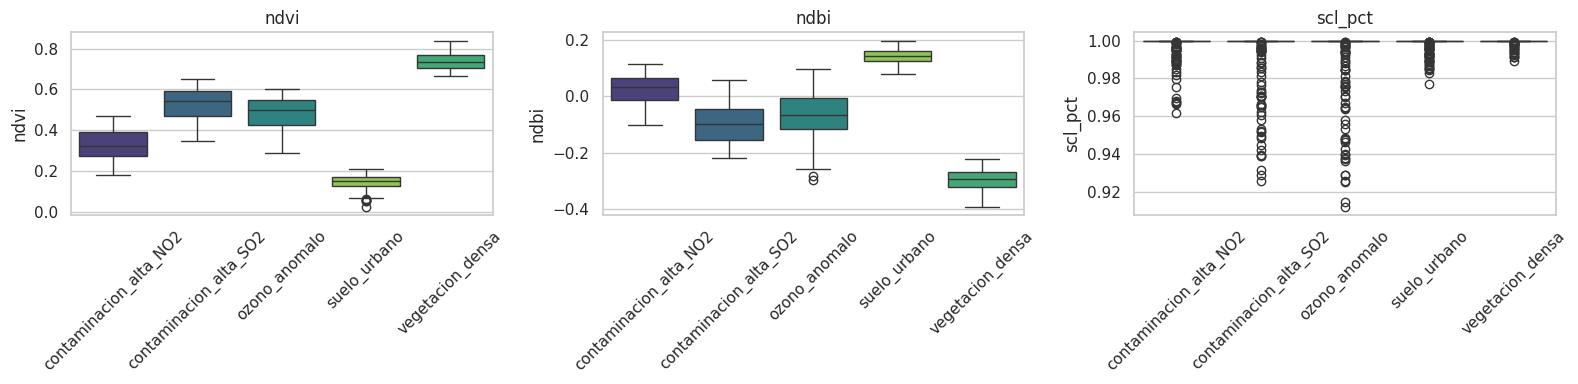

In [50]:
plt.figure(figsize=(10, 5))
sns.countplot(data=meta_df, y="clase", order=CLASES_ORDENADAS, hue="clase", palette="viridis", legend=False)
plt.title("Balance de clases del dataset v2")
plt.xlabel("Muestras")
plt.ylabel("Clase")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["ndvi", "ndbi", "scl_pct"]):
    sns.boxplot(data=meta_df, x="clase", y=col, hue="clase", order=CLASES_ORDENADAS, palette="viridis", ax=ax, legend=False)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [51]:
# NOTA: PROMPTS_BASE eliminado. Las captions vienen ahora del parquet (columna 'texto').
# Esto evita el leakage textual de incluir "Clase X" literal en el caption.

FEATURES_TABULARES = [
    "ndvi", "ndbi", "scl_pct",
    "era5_T2m", "era5_Td2m", "era5_u10", "era5_v10",
    "era5_BLH", "era5_RH850", "era5_psurf", "era5_precip",
    "modis_AOD_047", "modis_AOD_055", "modis_WV",
]

FEATURES_TABULARES = [c for c in FEATURES_TABULARES if c in meta_df.columns]
FEATURES_NO_LEAK = [c for c in FEATURES_TABULARES if c not in ["no2", "so2", "o3"]]

print(f"Features tabulares sin leakage: {FEATURES_NO_LEAK}")
print(f"Captions del parquet: {meta_df['texto'].nunique()} unicas / {len(meta_df)} ({meta_df['texto'].nunique()/len(meta_df):.2%})")
print(f"sample caption: {meta_df['texto'].iloc[0]}")

Features tabulares sin leakage: ['ndvi', 'ndbi', 'scl_pct', 'era5_T2m', 'era5_Td2m', 'era5_u10', 'era5_v10', 'era5_BLH', 'era5_RH850', 'era5_psurf', 'era5_precip', 'modis_AOD_047', 'modis_AOD_055', 'modis_WV']
Captions del parquet: 918 unicas / 1500 (61.20%)
sample caption: imagen multiespectral con NO2 marcado en el norte de Cali, vegetación moderada y superficie predominantemente natural; con patrón espacial típico de emisión antrópica


In [52]:
# Las captions del parquet ya estan limpias (sin numeros ni nombres de clase).
# Se usan directamente, sin regenerarlas.
meta_df = meta_df.reset_index(drop=True).copy()

print(meta_df[["clase", "texto"]].head())
print()
print("Captions unicas por clase:")
for c in CLASES_ORDENADAS:
    sub = meta_df[meta_df.clase == c]
    print(f"  {c:30s} | {sub.texto.nunique():3d}/{len(sub)} ({sub.texto.nunique()/len(sub):.2%})")

                    clase                                              texto
0  contaminacion_alta_NO2  imagen multiespectral con NO2 marcado en el no...
1  contaminacion_alta_NO2  tile con firma de combustión vehicular sobre e...
2  contaminacion_alta_NO2  tile con firma de combustión vehicular sobre e...
3  contaminacion_alta_NO2  paisaje con concentración alta de óxidos de ni...
4  contaminacion_alta_NO2  tile con firma de combustión vehicular sobre e...

Captions unicas por clase:
  contaminacion_alta_NO2         | 219/300 (73.00%)
  contaminacion_alta_SO2         | 181/300 (60.33%)
  ozono_anomalo                  | 179/300 (59.67%)
  suelo_urbano                   | 165/300 (55.00%)
  vegetacion_densa               | 174/300 (58.00%)


In [53]:
indices = np.arange(len(meta_df))
labels = meta_df["clase"].values

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=labels,
    random_state=SEED,
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=labels[temp_idx],
    random_state=SEED,
)

print(f"Train: {len(train_idx)}")
print(f"Val:   {len(val_idx)}")
print(f"Test:  {len(test_idx)}")

for nombre, idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    print(f"\n{nombre}")
    print(meta_df.iloc[idx]["clase"].value_counts().reindex(CLASES_ORDENADAS))

Train: 1050
Val:   225
Test:  225

train
clase
contaminacion_alta_NO2    210
contaminacion_alta_SO2    210
ozono_anomalo             210
suelo_urbano              210
vegetacion_densa          210
Name: count, dtype: int64

val
clase
contaminacion_alta_NO2    45
contaminacion_alta_SO2    45
ozono_anomalo             45
suelo_urbano              45
vegetacion_densa          45
Name: count, dtype: int64

test
clase
contaminacion_alta_NO2    45
contaminacion_alta_SO2    45
ozono_anomalo             45
suelo_urbano              45
vegetacion_densa          45
Name: count, dtype: int64


In [54]:
class GeoVisionClipDataset(Dataset):
    def __init__(self, images, metadata, indices, tabular_cols, class_list, scaler=None, fit_scaler=False):
        self.images = images
        self.metadata = metadata.iloc[indices].reset_index(drop=True).copy()
        self.indices = np.asarray(indices)
        self.tabular_cols = tabular_cols
        self.class_to_idx = {c: i for i, c in enumerate(class_list)}

        tab = self.metadata[tabular_cols].copy()
        for col in tab.columns:
            tab[col] = tab[col].fillna(tab[col].median())

        if scaler is None:
            scaler = StandardScaler()
        self.scaler = scaler
        self.tabular = scaler.fit_transform(tab) if fit_scaler else scaler.transform(tab)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        raw_idx = self.indices[idx]
        img = torch.tensor(self.images[raw_idx], dtype=torch.float32)
        tab = torch.tensor(self.tabular[idx], dtype=torch.float32)
        label = self.class_to_idx[self.metadata.loc[idx, "clase"]]
        text = self.metadata.loc[idx, "texto"]
        return img, tab, label, text

train_dataset = GeoVisionClipDataset(images_raw, meta_df, train_idx, FEATURES_NO_LEAK, CLASES_ORDENADAS, fit_scaler=True)
val_dataset = GeoVisionClipDataset(images_raw, meta_df, val_idx, FEATURES_NO_LEAK, CLASES_ORDENADAS, scaler=train_dataset.scaler)
test_dataset = GeoVisionClipDataset(images_raw, meta_df, test_idx, FEATURES_NO_LEAK, CLASES_ORDENADAS, scaler=train_dataset.scaler)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("DataLoaders listos")

DataLoaders listos


In [55]:
N_CANDIDATOS_POR_CLASE = 5

TEXTOS_CANDIDATOS = []
TEXTOS_CANDIDATOS_LABELS = []

train_meta = meta_df.iloc[train_idx]
for clase_idx, clase in enumerate(CLASES_ORDENADAS):
    sub = train_meta[train_meta.clase == clase]
    captions_unicas = sub.texto.drop_duplicates()
    n = min(N_CANDIDATOS_POR_CLASE, len(captions_unicas))
    sample = captions_unicas.sample(n=n, random_state=SEED).tolist()
    for t in sample:
        TEXTOS_CANDIDATOS.append(t)
        TEXTOS_CANDIDATOS_LABELS.append(clase_idx)

TEXTOS_CANDIDATOS_LABELS = torch.tensor(TEXTOS_CANDIDATOS_LABELS, dtype=torch.long)

print(f"Textos candidatos para retrieval: {len(TEXTOS_CANDIDATOS)} ({N_CANDIDATOS_POR_CLASE} por clase, sampleados del train)")
for texto, label in zip(TEXTOS_CANDIDATOS[:5], TEXTOS_CANDIDATOS_LABELS[:5]):
    print(f"[{CLASES_ORDENADAS[label]}] {texto[:120]}")

Textos candidatos para retrieval: 25 (5 por clase, sampleados del train)
[contaminacion_alta_NO2] tile con firma de combustión vehicular sobre el sur de Cali, superficie predominantemente natural; compatible con tráfic
[contaminacion_alta_NO2] paisaje con concentración alta de óxidos de nitrógeno sobre el occidente de Cali en periodo de veranillo, asociada a cen
[contaminacion_alta_NO2] tile con firma de combustión vehicular sobre el norte de Cali, superficie predominantemente natural; sugerente de fuente
[contaminacion_alta_NO2] imagen satelital con emisiones elevadas de NO2 en el norte de Cali, área parcialmente construida; asociada a centro urba
[contaminacion_alta_NO2] tile con firma de combustión vehicular sobre el suroccidente de Cali, superficie predominantemente natural; asociada a c


In [56]:
class BandProjector(nn.Module):
    def __init__(self, in_channels=13, out_channels=3, image_size=224):
        super().__init__()
        self.image_size = image_size
        self.proj = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=1),
            nn.GELU(),
            nn.Conv2d(32, out_channels, kernel_size=1),
        )
        self.register_buffer("mean", torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1, 3, 1, 1))

    def forward(self, x):
        x = x / 10000.0
        x = torch.clamp(x, 0.0, 1.5)
        x = self.proj(x)
        x = F.interpolate(x, size=(self.image_size, self.image_size), mode="bilinear", align_corners=False)
        x = torch.sigmoid(x)
        return (x - self.mean) / self.std

In [57]:
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=2048, sparse_dim=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, sparse_dim),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(sparse_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return z, recon

    @torch.no_grad()
    def resample_dead_neurons(self, x, z, threshold=1e-3):
        active = (z > 0).float().mean(dim=0)
        dead = active < threshold
        n_dead = int(dead.sum().item())
        return n_dead


class ProjectionHead(nn.Module):
    def __init__(self, input_dim=256, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.GELU(),
            nn.LayerNorm(input_dim),
            nn.Dropout(0.10),
            nn.Linear(input_dim, out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

In [58]:
def set_visual_trainable(visual_encoder, train_last_blocks=1):
    for p in visual_encoder.parameters():
        p.requires_grad = False

    if train_last_blocks > 0 and hasattr(visual_encoder, "transformer") and hasattr(visual_encoder.transformer, "resblocks"):
        for block in visual_encoder.transformer.resblocks[-train_last_blocks:]:
            for p in block.parameters():
                p.requires_grad = True

    for name in ["ln_post", "proj"]:
        module_or_param = getattr(visual_encoder, name, None)
        if isinstance(module_or_param, nn.Module):
            for p in module_or_param.parameters():
                p.requires_grad = True
        elif isinstance(module_or_param, nn.Parameter):
            module_or_param.requires_grad = True


def mean_pool_text(outputs, attention_mask):
    token_embeddings = outputs.last_hidden_state
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * mask, dim=1) / torch.clamp(mask.sum(dim=1), min=1e-9)

In [59]:
class GeoVisionCLIP(nn.Module):
    def __init__(self, n_tabular, n_classes):
        super().__init__()
        clip_model, _, _ = open_clip.create_model_and_transforms(
            "ViT-B-32",
            pretrained="laion2b_s34b_b79k",
        )

        self.band_projector = BandProjector(in_channels=CHANNELS_S2, out_channels=3, image_size=224)
        self.visual_encoder = clip_model.visual
        set_visual_trainable(self.visual_encoder, train_last_blocks=TRAIN_LAST_BLOCKS)

        self.text_model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
        self.text_tokenizer = AutoTokenizer.from_pretrained(self.text_model_name)
        self.text_encoder = AutoModel.from_pretrained(self.text_model_name)
        for p in self.text_encoder.parameters():
            p.requires_grad = False

        self.sae_visual = SparseAutoencoder(input_dim=512, hidden_dim=SAE_HIDDEN_VISUAL, sparse_dim=SAE_SPARSE_DIM)
        self.sae_text = SparseAutoencoder(input_dim=384, hidden_dim=SAE_HIDDEN_TEXT, sparse_dim=SAE_SPARSE_DIM)
        self.proj_visual = ProjectionHead(input_dim=SAE_SPARSE_DIM, out_dim=CONTRASTIVE_DIM)
        self.proj_text = ProjectionHead(input_dim=SAE_SPARSE_DIM, out_dim=CONTRASTIVE_DIM)

        self.tabular_gate = nn.Sequential(
            nn.Linear(n_tabular, 128),
            nn.GELU(),
            nn.Dropout(TABULAR_DROPOUT),
            nn.Linear(128, SAE_SPARSE_DIM),
            nn.Sigmoid(),
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(CONTRASTIVE_DIM),
            nn.Linear(CONTRASTIVE_DIM, n_classes),
        )

        self.logit_scale = nn.Parameter(torch.tensor(math.log(1 / TEMP_INIT)))

    def encode_image_raw(self, images):
        x = self.band_projector(images)
        return self.visual_encoder(x).float()

    def encode_text_raw(self, texts):
        tokens = self.text_tokenizer(
            list(texts),
            padding=True,
            truncation=True,
            max_length=96,
            return_tensors="pt",
        ).to(next(self.parameters()).device)
        with torch.no_grad():
            outputs = self.text_encoder(**tokens)
        return mean_pool_text(outputs, tokens["attention_mask"]).float()

    def encode_image(self, images, tabular):
        raw = self.encode_image_raw(images)
        z, recon = self.sae_visual(raw)
        gate = self.tabular_gate(tabular)
        z = z * (0.75 + 0.5 * gate)
        emb = self.proj_visual(z)
        logits_cls = self.classifier(emb)
        return emb, z, recon, raw, logits_cls

    def encode_text_features(self, raw_text):
        z, recon = self.sae_text(raw_text)
        emb = self.proj_text(z)
        return emb, z, recon

    def encode_text(self, texts):
        raw = self.encode_text_raw(texts)
        emb, z, recon = self.encode_text_features(raw)
        return emb, z, recon, raw

    def forward(self, images, tabular, texts):
        img_emb, z_img, recon_img, raw_img, logits_cls = self.encode_image(images, tabular)
        txt_emb, z_txt, recon_txt, raw_txt = self.encode_text(texts)
        return {
            "img_emb": img_emb,
            "txt_emb": txt_emb,
            "z_img": z_img,
            "z_txt": z_txt,
            "recon_img": recon_img,
            "recon_txt": recon_txt,
            "raw_img": raw_img,
            "raw_txt": raw_txt,
            "logits_cls": logits_cls,
        }

In [60]:
model = GeoVisionCLIP(
    n_tabular=len(FEATURES_NO_LEAK),
    n_classes=len(CLASES_ORDENADAS),
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Parámetros totales: {total:,}")
print(f"Parámetros entrenables: {trainable:,}")
print(f"Porcentaje entrenable: {100 * trainable / total:.2f}%")
print(f"Temperatura inicial: {model.logit_scale.exp().item():.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Parámetros totales: 210,280,745
Parámetros entrenables: 19,348,265
Porcentaje entrenable: 9.20%
Temperatura inicial: 14.2857


In [61]:
imgs, tabs, labels_batch, texts = next(iter(train_loader))
imgs = imgs.to(device)
tabs = tabs.to(device)

model.eval()
with torch.no_grad():
    out = model(imgs, tabs, texts)

print("Prueba forward")
print(f"img_emb:   {tuple(out['img_emb'].shape)}")
print(f"txt_emb:   {tuple(out['txt_emb'].shape)}")
print(f"z_img:     {tuple(out['z_img'].shape)}")
print(f"recon_img: {tuple(out['recon_img'].shape)}")
print(f"logits:    {tuple(out['logits_cls'].shape)}")

Prueba forward
img_emb:   (32, 256)
txt_emb:   (32, 256)
z_img:     (32, 256)
recon_img: (32, 512)
logits:    (32, 5)


In [62]:
def multipositive_infonce(img_emb, txt_emb, labels, text_labels, logit_scale):
    logits = logit_scale.exp().clamp(max=100.0) * img_emb @ txt_emb.t()
    pos_mask = labels[:, None].eq(text_labels[None, :]).float()
    log_den = torch.logsumexp(logits, dim=1)
    log_num = torch.logsumexp(logits.masked_fill(pos_mask == 0, -1e9), dim=1)
    return -(log_num - log_den).mean()


def sae_loss(recon, raw, z):
    recon_loss = F.mse_loss(recon, raw)
    sparse_loss = torch.norm(z, p=1, dim=-1).mean() * SAE_L1_REG
    return recon_loss + sparse_loss, recon_loss


@torch.no_grad()
def recall_at_k_from_logits(logits, labels, text_labels, k):
    topk = logits.topk(k, dim=1).indices
    pred_labels = text_labels[topk]
    return pred_labels.eq(labels[:, None]).any(dim=1).float().mean().item()


@torch.no_grad()
def late_fusion_logits(clip_logits, class_logits, text_labels, beta=0.25):
    class_scores = F.log_softmax(class_logits, dim=1)
    class_by_text = class_scores[:, text_labels]
    return clip_logits + beta * class_by_text

In [63]:
def evaluar_retrieval(model, loader, candidate_texts, candidate_labels, fusion_betas=(0.0, 0.15, 0.25, 0.35)):
    model.eval()
    candidate_labels = candidate_labels.to(device)

    with torch.no_grad():
        txt_emb, z_txt, recon_txt, raw_txt = model.encode_text(candidate_texts)

    total_loss = 0.0
    total_n = 0
    all_logits = []
    all_labels = []
    all_z_img = []
    all_raw_img = []
    all_recon_img = []
    all_cls_logits = []

    with torch.no_grad():
        for imgs, tabs, labels, _ in loader:
            imgs = imgs.to(device)
            tabs = tabs.to(device)
            labels = labels.to(device)

            img_emb, z_img, recon_img, raw_img, logits_cls = model.encode_image(imgs, tabs)
            loss_nce = multipositive_infonce(img_emb, txt_emb, labels, candidate_labels, model.logit_scale)
            loss_img, _ = sae_loss(recon_img, raw_img, z_img)
            loss_txt, _ = sae_loss(recon_txt, raw_txt, z_txt)
            loss_cls = F.cross_entropy(logits_cls, labels, label_smoothing=LABEL_SMOOTHING)
            loss = loss_nce + ALPHA_SAE * (loss_img + loss_txt) + AUX_CLS_WEIGHT * loss_cls

            logits = model.logit_scale.exp().clamp(max=100.0) * img_emb @ txt_emb.t()
            all_logits.append(logits.cpu())
            all_labels.append(labels.cpu())
            all_z_img.append(z_img.cpu())
            all_raw_img.append(raw_img.cpu())
            all_recon_img.append(recon_img.cpu())
            all_cls_logits.append(logits_cls.cpu())

            bs = labels.size(0)
            total_loss += loss.item() * bs
            total_n += bs

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    all_z_img = torch.cat(all_z_img)
    all_raw_img = torch.cat(all_raw_img)
    all_recon_img = torch.cat(all_recon_img)
    all_cls_logits = torch.cat(all_cls_logits)
    candidate_labels_cpu = candidate_labels.cpu()

    metrics = {
        "loss": total_loss / total_n,
        "recall1": recall_at_k_from_logits(all_logits, all_labels, candidate_labels_cpu, 1),
        "recall5": recall_at_k_from_logits(all_logits, all_labels, candidate_labels_cpu, 5),
        "sparsity": (all_z_img < SPARSITY_KPI_THRESH).float().mean().item(),
        "mse": F.mse_loss(all_recon_img, all_raw_img).item(),
    }

    best_beta = 0.0
    best_r1 = metrics["recall1"]
    best_r5 = metrics["recall5"]

    for beta in fusion_betas:
        fused = late_fusion_logits(all_logits, all_cls_logits, candidate_labels_cpu, beta=beta)
        r1 = recall_at_k_from_logits(fused, all_labels, candidate_labels_cpu, 1)
        r5 = recall_at_k_from_logits(fused, all_labels, candidate_labels_cpu, 5)
        metrics[f"recall1_fusion_beta_{beta}"] = r1
        metrics[f"recall5_fusion_beta_{beta}"] = r5
        if r1 > best_r1:
            best_beta = beta
            best_r1 = r1
            best_r5 = r5

    metrics["best_beta"] = best_beta
    metrics["recall1_fusion"] = best_r1
    metrics["recall5_fusion"] = best_r5
    return metrics

In [64]:
param_groups = [
    {"params": model.band_projector.parameters(), "lr": 1e-4, "weight_decay": 1e-4},
    {"params": [p for p in model.visual_encoder.parameters() if p.requires_grad], "lr": 1e-5, "weight_decay": 1e-2},
    {"params": model.sae_visual.parameters(), "lr": 3e-4, "weight_decay": 1e-4},
    {"params": model.sae_text.parameters(), "lr": 3e-4, "weight_decay": 1e-4},
    {"params": model.proj_visual.parameters(), "lr": 5e-4, "weight_decay": 1e-4},
    {"params": model.proj_text.parameters(), "lr": 5e-4, "weight_decay": 1e-4},
    {"params": model.classifier.parameters(), "lr": 3e-4, "weight_decay": 1e-4},
    {"params": model.tabular_gate.parameters(), "lr": 1e-4, "weight_decay": 1e-4},
    {"params": [model.logit_scale], "lr": 1e-3, "weight_decay": 0.0},
]

optimizer = torch.optim.AdamW(param_groups, betas=(0.9, 0.98), eps=1e-6)

total_steps = math.ceil(len(train_loader) / GRAD_ACCUM) * EPOCHS
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[g["lr"] for g in param_groups],
    total_steps=total_steps,
    pct_start=0.10,
    anneal_strategy="cos",
    div_factor=25.0,
    final_div_factor=1e4,
)

TEXTOS_CANDIDATOS_LABELS = TEXTOS_CANDIDATOS_LABELS.to(device)

historial = []
best_score = -1.0
best_val_loss = float("inf")
best_epoch = 0
paciencia = 8
ckpt_path = RUTA_SALIDA / "best_geovision_clip_sit2.pt"

In [65]:
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    train_nce = 0.0
    train_sae_img = 0.0
    train_sae_txt = 0.0
    train_cls = 0.0
    train_n = 0

    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(train_loader, desc=f"Epoca {epoch}/{EPOCHS}")
    for step, (imgs, tabs, labels, texts) in enumerate(pbar, start=1):
        imgs = imgs.to(device)
        tabs = tabs.to(device)
        labels = labels.to(device)

        out = model(imgs, tabs, texts)
        txt_bank_emb, z_txt_bank, recon_txt_bank, raw_txt_bank = model.encode_text(TEXTOS_CANDIDATOS)

        loss_nce = multipositive_infonce(
            out["img_emb"],
            txt_bank_emb,
            labels,
            TEXTOS_CANDIDATOS_LABELS,
            model.logit_scale,
        )
        loss_img, mse_img = sae_loss(out["recon_img"], out["raw_img"], out["z_img"])
        loss_txt, mse_txt = sae_loss(recon_txt_bank, raw_txt_bank, z_txt_bank)
        loss_cls = F.cross_entropy(out["logits_cls"], labels, label_smoothing=LABEL_SMOOTHING)
        loss = loss_nce + ALPHA_SAE * (loss_img + loss_txt) + AUX_CLS_WEIGHT * loss_cls
        loss_to_backprop = loss / GRAD_ACCUM

        loss_to_backprop.backward()

        if step % GRAD_ACCUM == 0 or step == len(train_loader):
            torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            model.logit_scale.data.clamp_(max=math.log(100.0))

        model.sae_visual.resample_dead_neurons(out["raw_img"].detach(), out["z_img"].detach(), threshold=SAE_DEAD_THRESHOLD)
        model.sae_text.resample_dead_neurons(raw_txt_bank.detach(), z_txt_bank.detach(), threshold=SAE_DEAD_THRESHOLD)

        bs = labels.size(0)
        train_loss += loss.item() * bs
        train_nce += loss_nce.item() * bs
        train_sae_img += loss_img.item() * bs
        train_sae_txt += loss_txt.item() * bs
        train_cls += loss_cls.item() * bs
        train_n += bs

        pbar.set_postfix({
            "loss": f"{loss.item():.3f}",
            "nce": f"{loss_nce.item():.3f}",
            "cls": f"{loss_cls.item():.3f}",
        })

    val_metrics = evaluar_retrieval(model, val_loader, TEXTOS_CANDIDATOS, TEXTOS_CANDIDATOS_LABELS)
    train_row = {
        "epoch": epoch,
        "train_loss": train_loss / train_n,
        "train_info_nce": train_nce / train_n,
        "train_sae_img": train_sae_img / train_n,
        "train_sae_txt": train_sae_txt / train_n,
        "train_cls": train_cls / train_n,
        "val_loss": val_metrics["loss"],
        "val_recall1": val_metrics["recall1"],
        "val_recall5": val_metrics["recall5"],
        "val_recall1_fusion": val_metrics["recall1_fusion"],
        "val_recall5_fusion": val_metrics["recall5_fusion"],
        "best_beta": val_metrics["best_beta"],
        "val_sparsity": val_metrics["sparsity"],
        "val_mse": val_metrics["mse"],
        "temperature": model.logit_scale.exp().item(),
    }
    historial.append(train_row)

    print(
        f"Epoca {epoch:02d} | "
        f"loss={train_row['train_loss']:.4f} | "
        f"val_loss={train_row['val_loss']:.4f} | "
        f"R@1={train_row['val_recall1']:.4f} | "
        f"R@1_fusion={train_row['val_recall1_fusion']:.4f} | "
        f"beta={train_row['best_beta']:.2f} | "
        f"R@5={train_row['val_recall5']:.4f} | "
        f"sparsity={train_row['val_sparsity']:.4f} | "
        f"mse={train_row['val_mse']:.4f}"
    )

    improved = (train_row["val_recall1_fusion"] > best_score) or (
        train_row["val_recall1_fusion"] == best_score and train_row["val_loss"] < best_val_loss
    )

    if improved:
        best_score = train_row["val_recall1_fusion"]
        best_val_loss = train_row["val_loss"]
        best_epoch = epoch
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "config": {
                "classes": CLASES_ORDENADAS,
                "features": FEATURES_NO_LEAK,
                "contrastive_dim": CONTRASTIVE_DIM,
                "sae_sparse_dim": SAE_SPARSE_DIM,
                "sae_hidden_visual": SAE_HIDDEN_VISUAL,
                "sae_hidden_text": SAE_HIDDEN_TEXT,
                "temp_init": TEMP_INIT,
                "seed": SEED,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "aux_cls_weight": AUX_CLS_WEIGHT,
                "label_smoothing": LABEL_SMOOTHING,
                "sae_l1_reg": SAE_L1_REG,
                "train_last_blocks": TRAIN_LAST_BLOCKS,
                "tabular_dropout": TABULAR_DROPOUT,
                "best_beta": train_row["best_beta"],
            },
            "candidate_texts": TEXTOS_CANDIDATOS,
            "candidate_labels": TEXTOS_CANDIDATOS_LABELS.cpu(),
            "history": historial,
        }, ckpt_path)

    if epoch - best_epoch >= paciencia:
        print(f"Early stopping en epoca {epoch}. Mejor epoca: {best_epoch}")
        break

Epoca 1/30:   0%|          | 0/32 [00:00<?, ?it/s]

Epoca 01 | loss=2.2896 | val_loss=2.0856 | R@1=0.3289 | R@1_fusion=0.3422 | beta=0.15 | R@5=0.7378 | sparsity=0.5037 | mse=0.1595


Epoca 2/30:   0%|          | 0/32 [00:00<?, ?it/s]

Epoca 02 | loss=1.8913 | val_loss=1.8357 | R@1=0.4178 | R@1_fusion=0.4178 | beta=0.00 | R@5=0.7911 | sparsity=0.6476 | mse=0.0393


Epoca 3/30:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoca 28 | loss=0.8187 | val_loss=1.0980 | R@1=0.6444 | R@1_fusion=0.6756 | beta=0.25 | R@5=0.9067 | sparsity=0.7921 | mse=0.0098


Epoca 29/30:   0%|          | 0/32 [00:00<?, ?it/s]

Epoca 29 | loss=0.8110 | val_loss=1.0872 | R@1=0.6222 | R@1_fusion=0.6622 | beta=0.35 | R@5=0.9156 | sparsity=0.7924 | mse=0.0099


Epoca 30/30:   0%|          | 0/32 [00:00<?, ?it/s]

Epoca 30 | loss=0.8001 | val_loss=1.0863 | R@1=0.6222 | R@1_fusion=0.6667 | beta=0.35 | R@5=0.9156 | sparsity=0.7925 | mse=0.0099


,epoch,train_loss,train_info_nce,train_sae_img,train_sae_txt,train_cls,val_loss,val_recall1,val_recall5,val_recall1_fusion,val_recall5_fusion,best_beta,val_sparsity,val_mse,temperature
25,26,0.841110,0.551677,0.054403,0.052275,0.704915,1.091681,0.644444,0.893333,0.675556,0.871111,0.35,0.791510,0.009770,14.060275
26,27,0.835231,0.547615,0.054161,0.052094,0.700447,1.087196,0.653333,0.911111,0.662222,0.884444,0.35,0.791979,0.009865,14.062636
27,28,0.818654,0.532624,0.053797,0.051912,0.696577,1.097960,0.644444,0.906667,0.675556,0.888889,0.25,0.792066,0.009821,14.063618
28,29,0.810971,0.527492,0.053670,0.051856,0.690232,1.087190,0.622222,0.915556,0.662222,0.880000,0.35,0.792413,0.009863,14.064413
29,30,0.800105,0.519963,0.053553,0.051818,0.681915,1.086330,0.622222,0.915556,0.666667,0.880000,0.35,0.792500,0.009860,14.064537


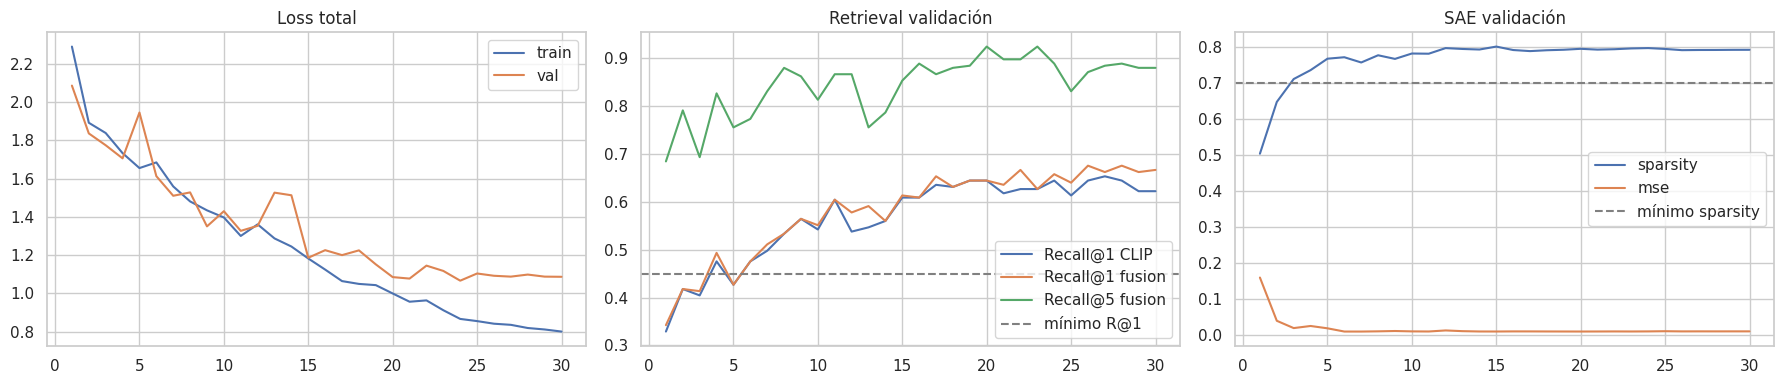

In [66]:
hist_df = pd.DataFrame(historial)
hist_df.to_csv(RUTA_SALIDA / "historial_entrenamiento.csv", index=False)
display(hist_df.tail())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val")
axes[0].set_title("Loss total")
axes[0].legend()

axes[1].plot(hist_df["epoch"], hist_df["val_recall1"], label="Recall@1 CLIP")
axes[1].plot(hist_df["epoch"], hist_df["val_recall1_fusion"], label="Recall@1 fusion")
axes[1].plot(hist_df["epoch"], hist_df["val_recall5_fusion"], label="Recall@5 fusion")
axes[1].axhline(0.45, linestyle="--", color="gray", label="mínimo R@1")
axes[1].set_title("Retrieval validación")
axes[1].legend()

axes[2].plot(hist_df["epoch"], hist_df["val_sparsity"], label="sparsity")
axes[2].plot(hist_df["epoch"], hist_df["val_mse"], label="mse")
axes[2].axhline(0.70, linestyle="--", color="gray", label="mínimo sparsity")
axes[2].set_title("SAE validación")
axes[2].legend()

plt.tight_layout()
plt.savefig(RUTA_SALIDA / "curvas_entrenamiento.png", dpi=160, bbox_inches="tight")
plt.show()

In [67]:
ARTEFACTO_DIR = Path("/kaggle/working/geovision_clip_model_dataset")
ARTEFACTO_DIR.mkdir(parents=True, exist_ok=True)

checkpoint = torch.load(ckpt_path, map_location="cpu")
modelo_path = ARTEFACTO_DIR / "geovision_clip_sit2_best.pt"
torch.save(checkpoint, modelo_path)

hist_df = pd.DataFrame(checkpoint["history"])
hist_df.to_csv(ARTEFACTO_DIR / "historial_entrenamiento.csv", index=False)

pd.DataFrame({
    "texto": checkpoint["candidate_texts"],
    "label_idx": checkpoint["candidate_labels"].numpy(),
    "clase": [CLASES_ORDENADAS[i] for i in checkpoint["candidate_labels"].numpy()],
}).to_csv(ARTEFACTO_DIR / "textos_candidatos.csv", index=False)

with open(ARTEFACTO_DIR / "config_modelo.json", "w", encoding="utf-8") as f:
    json.dump(checkpoint["config"], f, ensure_ascii=False, indent=2)

print(f"Artefacto guardado en: {ARTEFACTO_DIR}")
print(f"Checkpoint: {modelo_path}")

Artefacto guardado en: /kaggle/working/geovision_clip_model_dataset
Checkpoint: /kaggle/working/geovision_clip_model_dataset/geovision_clip_sit2_best.pt


In [68]:
def calcular_md5(path, chunk_size=1024 * 1024):
    md5 = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            md5.update(chunk)
    return md5.hexdigest()

md5_modelo = calcular_md5(modelo_path)

with open(ARTEFACTO_DIR / "MD5SUMS.txt", "w", encoding="utf-8") as f:
    f.write(f"{md5_modelo}  {modelo_path.name}\n")

print(f"MD5 checkpoint: {md5_modelo}")

MD5 checkpoint: a8e6cd3e16f8d1ea64ddb98b67b68bfb


In [69]:
manifest_modelo = {
    "nombre": "geovision_clip_sit2_best",
    "archivo": modelo_path.name,
    "md5": md5_modelo,
    "ruta_kaggle_working": str(modelo_path),
    "dataset_base": str(RUTA_DATASET),
    "clases": CLASES_ORDENADAS,
    "features_no_leak": FEATURES_NO_LEAK,
    "best_epoch": int(checkpoint["epoch"]),
    "best_beta": float(checkpoint["config"].get("best_beta", 0.0)),
    "seed": SEED,
    "nota": "Artefacto listo para crear Kaggle Dataset desde /kaggle/working/geovision_clip_model_dataset",
}

with open(ARTEFACTO_DIR / "manifest_modelo.json", "w", encoding="utf-8") as f:
    json.dump(manifest_modelo, f, ensure_ascii=False, indent=2)

print(json.dumps(manifest_modelo, ensure_ascii=False, indent=2))

{
  "nombre": "geovision_clip_sit2_best",
  "archivo": "geovision_clip_sit2_best.pt",
  "md5": "a8e6cd3e16f8d1ea64ddb98b67b68bfb",
  "ruta_kaggle_working": "/kaggle/working/geovision_clip_model_dataset/geovision_clip_sit2_best.pt",
  "dataset_base": "/kaggle/input/datasets/edwardsx/tiles-rescate-1500",
  "clases": [
    "contaminacion_alta_NO2",
    "contaminacion_alta_SO2",
    "ozono_anomalo",
    "suelo_urbano",
    "vegetacion_densa"
  ],
  "features_no_leak": [
    "ndvi",
    "ndbi",
    "scl_pct",
    "era5_T2m",
    "era5_Td2m",
    "era5_u10",
    "era5_v10",
    "era5_BLH",
    "era5_RH850",
    "era5_psurf",
    "era5_precip",
    "modis_AOD_047",
    "modis_AOD_055",
    "modis_WV"
  ],
  "best_epoch": 26,
  "best_beta": 0.35,
  "seed": 42,
  "nota": "Artefacto listo para crear Kaggle Dataset desde /kaggle/working/geovision_clip_model_dataset"
}


In [70]:
DATASET_SLUG = "edwardsx/geovision-clip-sit2-model"

metadata_kaggle = {
    "title": "GeoVision CLIP Sit2 Model",
    "id": DATASET_SLUG,
    "licenses": [{"name": "CC0-1.0"}],
}

with open(ARTEFACTO_DIR / "dataset-metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata_kaggle, f, ensure_ascii=False, indent=2)

print("Archivos listos para Kaggle Dataset")
for p in sorted(ARTEFACTO_DIR.iterdir()):
    print(f"{p.name}: {p.stat().st_size / 1024**2:.2f} MB")

Archivos listos para Kaggle Dataset
MD5SUMS.txt: 0.00 MB
config_modelo.json: 0.00 MB
dataset-metadata.json: 0.00 MB
diagnostico_errores_test.csv: 0.13 MB
diagnostico_so2_scores.png: 0.14 MB
geovision_clip_sit2_best.pt: 802.33 MB
historial_entrenamiento.csv: 0.01 MB
manifest_modelo.json: 0.00 MB
matriz_confusion_test.csv: 0.00 MB
matriz_confusion_test.png: 0.08 MB
metricas_test_rubrica.csv: 0.00 MB
resumen_scores_por_clase.csv: 0.00 MB
textos_candidatos.csv: 0.00 MB


In [71]:
import subprocess

cmd_create = [
    "kaggle",
    "datasets",
    "create",
    "-p",
    str(ARTEFACTO_DIR),
    "--public",
]

resultado = subprocess.run(cmd_create, capture_output=True, text=True)
print("STDOUT:")
print(resultado.stdout)
print("STDERR:")
print(resultado.stderr)

if resultado.returncode != 0:
    raise RuntimeError("Falló la creación del dataset. Si ya existe, usa la celda de versionado.")

print(f"Dataset creado: https://www.kaggle.com/datasets/{DATASET_SLUG}")

STDOUT:
Dataset creation error: The requested title "GeoVision CLIP Sit2 Model" is already in use by a dataset. Please choose another title.

STDERR:

Dataset creado: https://www.kaggle.com/datasets/edwardsx/geovision-clip-sit2-model


In [72]:
cmd_version = [
    "kaggle",
    "datasets",
    "version",
    "-p",
    str(ARTEFACTO_DIR),
    "-m",
    "Actualiza modelo GeoVision-CLIP Sit2",
]

resultado = subprocess.run(cmd_version, capture_output=True, text=True)
print("STDOUT:")
print(resultado.stdout)
print("STDERR:")
print(resultado.stderr)

if resultado.returncode != 0:
    raise RuntimeError("Falló la actualización del dataset.")

print(f"Dataset actualizado: https://www.kaggle.com/datasets/{DATASET_SLUG}")

STDOUT:
Starting upload for file diagnostico_so2_scores.png
Upload successful: diagnostico_so2_scores.png (141KB)
Starting upload for file matriz_confusion_test.csv
Upload successful: matriz_confusion_test.csv (238B)
Starting upload for file metricas_test_rubrica.csv
Upload successful: metricas_test_rubrica.csv (268B)
Starting upload for file matriz_confusion_test.png
Upload successful: matriz_confusion_test.png (87KB)
Starting upload for file textos_candidatos.csv
Upload successful: textos_candidatos.csv (4KB)
Starting upload for file config_modelo.json
Upload successful: config_modelo.json (741B)
Starting upload for file geovision_clip_sit2_best.pt
Upload successful: geovision_clip_sit2_best.pt (802MB)
Starting upload for file MD5SUMS.txt
Upload successful: MD5SUMS.txt (62B)
Starting upload for file diagnostico_errores_test.csv
Upload successful: diagnostico_errores_test.csv (130KB)
Starting upload for file historial_entrenamiento.csv
Upload successful: historial_entrenamiento.csv (7

In [73]:
checkpoint = torch.load(modelo_path, map_location=device)
model.load_state_dict(checkpoint["model_state"])
model.to(device)
model.eval()

TEXTOS_EVAL = checkpoint["candidate_texts"]
LABELS_EVAL = checkpoint["candidate_labels"].to(device)
BETA_EVAL = float(checkpoint["config"].get("best_beta", 0.0))

print(f"Checkpoint cargado desde: {modelo_path}")
print(f"Época seleccionada: {checkpoint['epoch']}")
print(f"Beta Late Fusion: {BETA_EVAL:.2f}")

Checkpoint cargado desde: /kaggle/working/geovision_clip_model_dataset/geovision_clip_sit2_best.pt
Época seleccionada: 26
Beta Late Fusion: 0.35


In [74]:
@torch.no_grad()
def evaluar_test_detallado(model, loader, candidate_texts, candidate_labels, beta):
    model.eval()
    candidate_labels = candidate_labels.to(device)
    txt_emb, z_txt, recon_txt, raw_txt = model.encode_text(candidate_texts)

    all_clip_logits = []
    all_fused_logits = []
    all_labels = []
    all_z_img = []
    all_raw_img = []
    all_recon_img = []
    all_cls_logits = []

    for imgs, tabs, labels, _ in loader:
        imgs = imgs.to(device)
        tabs = tabs.to(device)
        labels = labels.to(device)

        img_emb, z_img, recon_img, raw_img, cls_logits = model.encode_image(imgs, tabs)
        clip_logits = model.logit_scale.exp().clamp(max=100.0) * img_emb @ txt_emb.t()
        fused_logits = late_fusion_logits(clip_logits, cls_logits, candidate_labels, beta=beta)

        all_clip_logits.append(clip_logits.cpu())
        all_fused_logits.append(fused_logits.cpu())
        all_labels.append(labels.cpu())
        all_z_img.append(z_img.cpu())
        all_raw_img.append(raw_img.cpu())
        all_recon_img.append(recon_img.cpu())
        all_cls_logits.append(cls_logits.cpu())

    all_clip_logits = torch.cat(all_clip_logits)
    all_fused_logits = torch.cat(all_fused_logits)
    all_labels = torch.cat(all_labels)
    all_z_img = torch.cat(all_z_img)
    all_raw_img = torch.cat(all_raw_img)
    all_recon_img = torch.cat(all_recon_img)
    all_cls_logits = torch.cat(all_cls_logits)
    candidate_labels_cpu = candidate_labels.cpu()

    pred_text_idx = all_fused_logits.argmax(dim=1)
    pred_labels = candidate_labels_cpu[pred_text_idx]

    return {
        "clip_logits": all_clip_logits,
        "fused_logits": all_fused_logits,
        "labels": all_labels,
        "pred_labels": pred_labels,
        "z_img": all_z_img,
        "raw_img": all_raw_img,
        "recon_img": all_recon_img,
        "cls_logits": all_cls_logits,
        "candidate_labels": candidate_labels_cpu,
        "recall1_clip": recall_at_k_from_logits(all_clip_logits, all_labels, candidate_labels_cpu, 1),
        "recall5_clip": recall_at_k_from_logits(all_clip_logits, all_labels, candidate_labels_cpu, 5),
        "recall1_fusion": recall_at_k_from_logits(all_fused_logits, all_labels, candidate_labels_cpu, 1),
        "recall5_fusion": recall_at_k_from_logits(all_fused_logits, all_labels, candidate_labels_cpu, 5),
        "sparsity": (all_z_img < SPARSITY_KPI_THRESH).float().mean().item(),
        "mse": F.mse_loss(all_recon_img, all_raw_img).item(),
    }

test_eval = evaluar_test_detallado(model, test_loader, TEXTOS_EVAL, LABELS_EVAL, BETA_EVAL)

In [75]:
metricas_rubrica = pd.DataFrame([
    {
        "KPI": "Recall@1 imagen-texto",
        "valor": test_eval["recall1_fusion"],
        "minimo": 0.45,
        "excelente": 0.65,
        "cumple": test_eval["recall1_fusion"] >= 0.45,
    },
    {
        "KPI": "Recall@5 imagen-texto",
        "valor": test_eval["recall5_fusion"],
        "minimo": 0.70,
        "excelente": 0.85,
        "cumple": test_eval["recall5_fusion"] >= 0.70,
    },
    {
        "KPI": "Sparsity ratio SAE visual",
        "valor": test_eval["sparsity"],
        "minimo": 0.70,
        "excelente": 0.85,
        "cumple": test_eval["sparsity"] >= 0.70,
    },
    {
        "KPI": "Loss reconstrucción SAE",
        "valor": test_eval["mse"],
        "minimo": 0.05,
        "excelente": 0.02,
        "cumple": test_eval["mse"] <= 0.05,
    },
])

metricas_rubrica.to_csv(ARTEFACTO_DIR / "metricas_test_rubrica.csv", index=False)
display(metricas_rubrica)

print(f"Recall@1 CLIP puro: {test_eval['recall1_clip']:.4f}")
print(f"Recall@5 CLIP puro: {test_eval['recall5_clip']:.4f}")
print(f"Recall@1 fusion:    {test_eval['recall1_fusion']:.4f}")
print(f"Recall@5 fusion:    {test_eval['recall5_fusion']:.4f}")
print(f"Sparsity SAE:       {test_eval['sparsity']:.4f}")
print(f"MSE reconstrucción: {test_eval['mse']:.4f}")
print(f"MD5 checkpoint:     {md5_modelo}")

,KPI,valor,minimo,excelente,cumple
0,Recall@1 imagen-texto,0.653333,0.45,0.65,True
1,Recall@5 imagen-texto,0.848889,0.70,0.85,True
2,Sparsity ratio SAE visual,0.791684,0.70,0.85,True
3,Loss reconstrucción SAE,0.010633,0.05,0.02,True


Recall@1 CLIP puro: 0.6444
Recall@5 CLIP puro: 0.8889
Recall@1 fusion:    0.6533
Recall@5 fusion:    0.8489
Sparsity SAE:       0.7917
MSE reconstrucción: 0.0106
MD5 checkpoint:     a8e6cd3e16f8d1ea64ddb98b67b68bfb


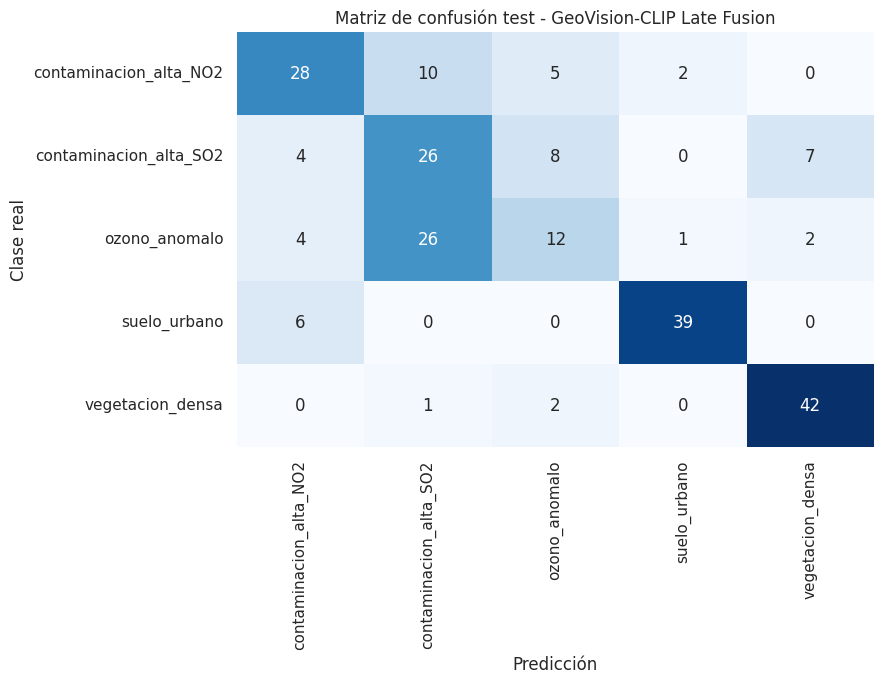

                        precision    recall  f1-score   support

contaminacion_alta_NO2     0.6667    0.6222    0.6437        45
contaminacion_alta_SO2     0.4127    0.5778    0.4815        45
         ozono_anomalo     0.4444    0.2667    0.3333        45
          suelo_urbano     0.9286    0.8667    0.8966        45
      vegetacion_densa     0.8235    0.9333    0.8750        45

              accuracy                         0.6533       225
             macro avg     0.6552    0.6533    0.6460       225
          weighted avg     0.6552    0.6533    0.6460       225



In [76]:
cm = confusion_matrix(
    test_eval["labels"].numpy(),
    test_eval["pred_labels"].numpy(),
    labels=list(range(len(CLASES_ORDENADAS))),
)

cm_df = pd.DataFrame(cm, index=CLASES_ORDENADAS, columns=CLASES_ORDENADAS)
cm_df.to_csv(ARTEFACTO_DIR / "matriz_confusion_test.csv")

plt.figure(figsize=(9, 7))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión test - GeoVision-CLIP Late Fusion")
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.tight_layout()
plt.savefig(ARTEFACTO_DIR / "matriz_confusion_test.png", dpi=160, bbox_inches="tight")
plt.show()

print(classification_report(
    test_eval["labels"].numpy(),
    test_eval["pred_labels"].numpy(),
    target_names=CLASES_ORDENADAS,
    digits=4,
))

In [77]:
def construir_df_errores(eval_dict, metadata, test_indices):
    df = metadata.iloc[test_indices].reset_index(drop=True).copy()
    labels_np = eval_dict["labels"].numpy()
    pred_np = eval_dict["pred_labels"].numpy()

    df["label_idx"] = labels_np
    df["pred_idx"] = pred_np
    df["clase_real"] = [CLASES_ORDENADAS[i] for i in labels_np]
    df["clase_pred"] = [CLASES_ORDENADAS[i] for i in pred_np]
    df["acierto"] = df["label_idx"] == df["pred_idx"]

    probs_cls = F.softmax(eval_dict["cls_logits"], dim=1).numpy()
    for i, clase in enumerate(CLASES_ORDENADAS):
        df[f"prob_cls_{clase}"] = probs_cls[:, i]

    fused = eval_dict["fused_logits"]
    clip = eval_dict["clip_logits"]
    candidate_labels = eval_dict["candidate_labels"]

    for clase_idx, clase in enumerate(CLASES_ORDENADAS):
        mask = candidate_labels.eq(clase_idx)
        df[f"score_fusion_{clase}"] = fused[:, mask].max(dim=1).values.numpy()
        df[f"score_clip_{clase}"] = clip[:, mask].max(dim=1).values.numpy()

    return df

df_errores = construir_df_errores(test_eval, meta_df, test_idx)
df_errores.to_csv(ARTEFACTO_DIR / "diagnostico_errores_test.csv", index=False)

print("Errores por clase real")
print(pd.crosstab(df_errores["clase_real"], df_errores["clase_pred"], margins=True))

Errores por clase real
clase_pred              contaminacion_alta_NO2  contaminacion_alta_SO2  \
clase_real                                                               
contaminacion_alta_NO2                      28                      10   
contaminacion_alta_SO2                       4                      26   
ozono_anomalo                                4                      26   
suelo_urbano                                 6                       0   
vegetacion_densa                             0                       1   
All                                         42                      63   

clase_pred              ozono_anomalo  suelo_urbano  vegetacion_densa  All  
clase_real                                                                  
contaminacion_alta_NO2              5             2                 0   45  
contaminacion_alta_SO2              8             0                 7   45  
ozono_anomalo                      12             1                 2   45  

In [78]:
for clase in CLASES_ORDENADAS:
    sub = df_errores[df_errores["clase_real"] == clase]
    print(f"\nClase real: {clase}")
    print(f"Aciertos: {sub['acierto'].sum()} / {len(sub)}")
    print("Predicciones:")
    print(sub["clase_pred"].value_counts())


Clase real: contaminacion_alta_NO2
Aciertos: 28 / 45
Predicciones:
clase_pred
contaminacion_alta_NO2    28
contaminacion_alta_SO2    10
ozono_anomalo              5
suelo_urbano               2
Name: count, dtype: int64

Clase real: contaminacion_alta_SO2
Aciertos: 26 / 45
Predicciones:
clase_pred
contaminacion_alta_SO2    26
ozono_anomalo              8
vegetacion_densa           7
contaminacion_alta_NO2     4
Name: count, dtype: int64

Clase real: ozono_anomalo
Aciertos: 12 / 45
Predicciones:
clase_pred
contaminacion_alta_SO2    26
ozono_anomalo             12
contaminacion_alta_NO2     4
vegetacion_densa           2
suelo_urbano               1
Name: count, dtype: int64

Clase real: suelo_urbano
Aciertos: 39 / 45
Predicciones:
clase_pred
suelo_urbano              39
contaminacion_alta_NO2     6
Name: count, dtype: int64

Clase real: vegetacion_densa
Aciertos: 42 / 45
Predicciones:
clase_pred
vegetacion_densa          42
ozono_anomalo              2
contaminacion_alta_SO2     1
Name

In [79]:
so2 = df_errores[df_errores["clase_real"] == "contaminacion_alta_SO2"].copy()
cols_so2 = [
    "clase_real", "clase_pred", "acierto", "ndvi", "ndbi", "scl_pct",
    "score_clip_contaminacion_alta_SO2",
    "score_clip_contaminacion_alta_NO2",
    "score_clip_ozono_anomalo",
    "score_clip_suelo_urbano",
    "score_clip_vegetacion_densa",
    "prob_cls_contaminacion_alta_SO2",
    "prob_cls_contaminacion_alta_NO2",
    "prob_cls_ozono_anomalo",
    "prob_cls_suelo_urbano",
    "prob_cls_vegetacion_densa",
]

cols_so2 = [c for c in cols_so2 if c in so2.columns]
display(so2[cols_so2].sort_values("prob_cls_contaminacion_alta_SO2", ascending=False).head(15))

,clase_real,clase_pred,acierto,ndvi,ndbi,scl_pct,score_clip_contaminacion_alta_SO2,score_clip_contaminacion_alta_NO2,score_clip_ozono_anomalo,score_clip_suelo_urbano,score_clip_vegetacion_densa,prob_cls_contaminacion_alta_SO2,prob_cls_contaminacion_alta_NO2,prob_cls_ozono_anomalo,prob_cls_suelo_urbano,prob_cls_vegetacion_densa
38,contaminacion_alta_SO2,contaminacion_alta_SO2,True,0.621028,-0.174700,1.000000,6.794405,3.520998,6.366702,-5.012572,4.877767,0.695115,0.035623,0.165105,0.003328,0.100829
127,contaminacion_alta_SO2,contaminacion_alta_SO2,True,0.502764,-0.124324,1.000000,7.759143,4.830715,7.477402,-4.994160,4.366229,0.658980,0.034117,0.263986,0.001760,0.041158
208,contaminacion_alta_SO2,contaminacion_alta_SO2,True,0.570345,-0.187115,1.000000,8.031658,4.405386,7.659379,-5.835643,5.602929,0.648881,0.029572,0.242972,0.001779,0.076796
118,contaminacion_alta_SO2,contaminacion_alta_SO2,True,0.576763,-0.127302,0.999023,8.129918,5.700902,7.751337,-4.497302,3.538316,0.637908,0.047083,0.292154,0.001552,0.021304
180,contaminacion_alta_SO2,contaminacion_alta_SO2,True,0.614495,-0.212480,1.000000,8.075225,6.288182,7.501848,-3.270374,2.520599,0.624597,0.086925,0.266886,0.002752,0.018840
142,contaminacion_alta_SO2,contaminacion_alta_SO2,True,0.623256,-0.210430,1.000000,7.210811,4.100764,7.042317,-5.173405,4.902259,0.609824,0.034046,0.259406,0.003681,0.093042
190,contaminacion_alta_SO2,contaminacion_alta_SO2,True,0.431503,-0.091115,0.966553,7.967023,6.345040,7.318573,-3.111324,2.393571,0.604306,0.120607,0.252186,0.002794,0.020107
158,contaminacion_alta_SO2,contaminacion_alta_SO2,True,0.615171,-0.208376,0.994629,6.362842,4.136367,6.245195,-4.042345,3.881074,0.574866,0.068447,0.235334,0.007481,0.113872
171,contaminacion_alta_SO2,contaminacion_alta_SO2,True,0.632600,-0.205030,1.000000,7.522842,5.123439,7.427404,-4.448990,3.535038,0.572668,0.039781,0.339796,0.004013,0.043741
5,contaminacion_alta_SO2,contaminacion_alta_SO2,True,0.578609,-0.074640,1.000000,7.979371,5.704672,7.728568,-4.344838,3.234137,0.566808,0.044946,0.360686,0.002708,0.024852


In [80]:
resumen_scores = []
for clase in CLASES_ORDENADAS:
    sub = df_errores[df_errores["clase_real"] == clase]
    fila = {"clase_real": clase, "n": len(sub), "accuracy": sub["acierto"].mean()}
    for pred in CLASES_ORDENADAS:
        fila[f"score_clip_{pred}_mean"] = sub[f"score_clip_{pred}"].mean()
        fila[f"prob_cls_{pred}_mean"] = sub[f"prob_cls_{pred}"].mean()
    resumen_scores.append(fila)

resumen_scores = pd.DataFrame(resumen_scores)
resumen_scores.to_csv(ARTEFACTO_DIR / "resumen_scores_por_clase.csv", index=False)
display(resumen_scores.round(4))

,clase_real,n,accuracy,score_clip_contaminacion_alta_NO2_mean,prob_cls_contaminacion_alta_NO2_mean,score_clip_contaminacion_alta_SO2_mean,prob_cls_contaminacion_alta_SO2_mean,score_clip_ozono_anomalo_mean,prob_cls_ozono_anomalo_mean,score_clip_suelo_urbano_mean,prob_cls_suelo_urbano_mean,score_clip_vegetacion_densa_mean,prob_cls_vegetacion_densa_mean
0,contaminacion_alta_NO2,45,0.6222,8.3513,0.4787,6.6183,0.2064,7.2464,0.2413,1.7650,0.0674,-2.0287,0.0061
1,contaminacion_alta_SO2,45,0.5778,5.3766,0.1218,7.2563,0.4178,7.0627,0.3255,-3.0984,0.0072,2.5019,0.1277
2,ozono_anomalo,45,0.2667,6.3748,0.1570,7.6059,0.3943,7.4787,0.3664,-2.3972,0.0217,1.5472,0.0607
3,suelo_urbano,45,0.8667,6.3833,0.1834,-1.9475,0.0097,0.7631,0.0193,9.0489,0.7808,-2.6809,0.0068
4,vegetacion_densa,45,0.9333,-1.8442,0.0107,2.5024,0.1055,2.5242,0.0824,-2.7771,0.0125,6.9885,0.7889


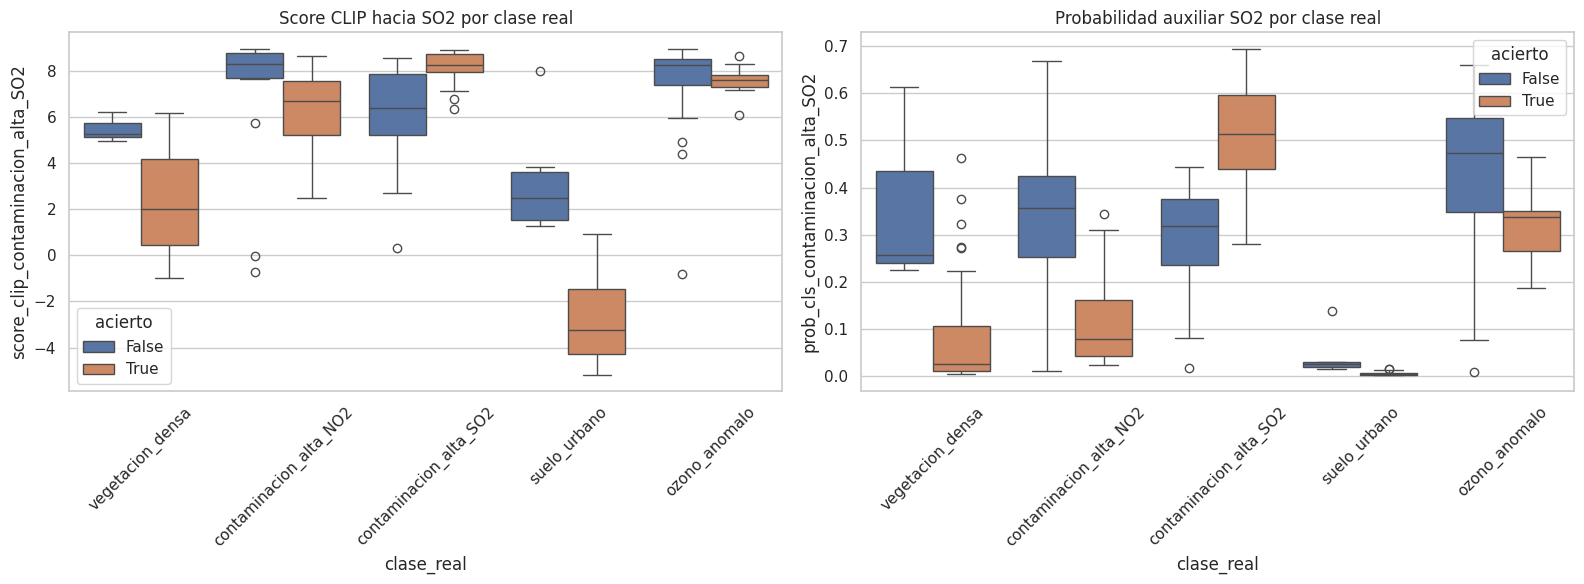

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=df_errores,
    x="clase_real",
    y="score_clip_contaminacion_alta_SO2",
    hue="acierto",
    ax=axes[0],
)
axes[0].set_title("Score CLIP hacia SO2 por clase real")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(
    data=df_errores,
    x="clase_real",
    y="prob_cls_contaminacion_alta_SO2",
    hue="acierto",
    ax=axes[1],
)
axes[1].set_title("Probabilidad auxiliar SO2 por clase real")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(ARTEFACTO_DIR / "diagnostico_so2_scores.png", dpi=160, bbox_inches="tight")
plt.show()

In [97]:
# 7.0 — Extraer embeddings raw visual (512-d) sobre TODO el dataset (train+val+test)
# Usar loaders de evaluación (shuffle=False, drop_last=False) para no perder tiles.
from torch.utils.data import DataLoader

model.load_state_dict(torch.load(modelo_path, map_location=device)["model_state"])
model.eval()

eval_loaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=False),
    'val':   DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=False),
    'test':  DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=False),
}

orden_idx = np.concatenate([train_idx, val_idx, test_idx])
meta_ordered = meta_df.iloc[orden_idx].reset_index(drop=True).copy()

raw_emb_list, z_emb_list, labels_list = [], [], []
with torch.no_grad():
    for name in ['train', 'val', 'test']:
        for imgs, tabs, labels, _ in eval_loaders[name]:
            imgs = imgs.to(device); tabs = tabs.to(device)
            _, z_img, _, raw_img, _ = model.encode_image(imgs, tabs)
            raw_emb_list.append(raw_img.cpu().numpy())
            z_emb_list.append(z_img.cpu().numpy())
            labels_list.append(labels.numpy())

emb_raw = np.concatenate(raw_emb_list, axis=0)
emb_sparse = np.concatenate(z_emb_list, axis=0)
labels_full = np.concatenate(labels_list, axis=0)

assert len(emb_raw) == len(meta_ordered), f"Mismatch: emb_raw={len(emb_raw)} vs meta_ordered={len(meta_ordered)}"
print(f"Embeddings raw visual: {emb_raw.shape}")
print(f"Embeddings sparse SAE: {emb_sparse.shape}")
print(f"Labels: {labels_full.shape}, balance: {np.bincount(labels_full)}")
print(f"meta_ordered: {len(meta_ordered)}  (alineado con embeddings)")

Embeddings raw visual: (1500, 512)
Embeddings sparse SAE: (1500, 256)
Labels: (1500,), balance: [300 300 300 300 300]
meta_ordered: 1500  (alineado con embeddings)


m para >=80% varianza: 11 factores
m para >=90% varianza: 27 factores
varianza acumulada @ m_80: 80.80%


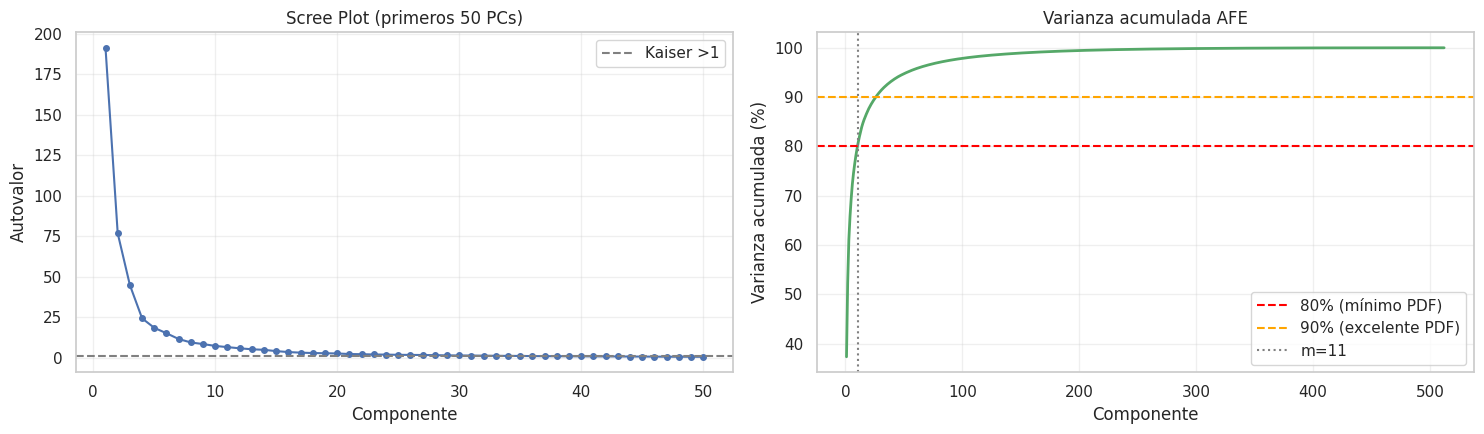

In [98]:
# 7.1 — AFE: PCA, Scree Plot, varianza acumulada
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler_emb = StandardScaler()
emb_std = scaler_emb.fit_transform(emb_raw)

pca = PCA()
pca.fit(emb_std)
cumvar = np.cumsum(pca.explained_variance_ratio_)
m_80 = int(np.argmax(cumvar >= 0.80) + 1)
m_90 = int(np.argmax(cumvar >= 0.90) + 1) if (cumvar >= 0.90).any() else len(cumvar)

print(f"m para >=80% varianza: {m_80} factores")
print(f"m para >=90% varianza: {m_90} factores")
print(f"varianza acumulada @ m_80: {cumvar[m_80-1]*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
n_show = min(50, len(pca.explained_variance_))
axes[0].plot(range(1, n_show+1), pca.explained_variance_[:n_show], 'b-o', markersize=4)
axes[0].axhline(1.0, ls='--', color='gray', label='Kaiser >1')
axes[0].set_xlabel('Componente'); axes[0].set_ylabel('Autovalor'); axes[0].set_title('Scree Plot (primeros 50 PCs)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(cumvar)+1), cumvar*100, 'g-', lw=2)
axes[1].axhline(80, ls='--', color='red', label='80% (mínimo PDF)')
axes[1].axhline(90, ls='--', color='orange', label='90% (excelente PDF)')
axes[1].axvline(m_80, ls=':', color='gray', label=f'm={m_80}')
axes[1].set_xlabel('Componente'); axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada AFE'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ARTEFACTO_DIR / 'afe_scree_plot.png', dpi=160, bbox_inches='tight')
plt.show()

Cargas rotadas shape: (512, 11)
Varianza con rotación Varimax:
  por factor:  [149.42787328 116.42840226  43.85637188  23.12536551  13.80494836
  16.883186    12.49052763   9.48133659   9.01897433   9.0785035
  10.08887455]
  proporcion:  [0.29185132 0.22739922 0.08565698 0.04516673 0.02696279 0.03297497
 0.02439556 0.01851824 0.01761518 0.01773145 0.01970483]
  acumulada:   [0.29185132 0.51925054 0.60490751 0.65007424 0.67703703 0.71001201
 0.73440757 0.7529258  0.77054099 0.78827244 0.80797727]
  TOTAL acumulado: 80.80%


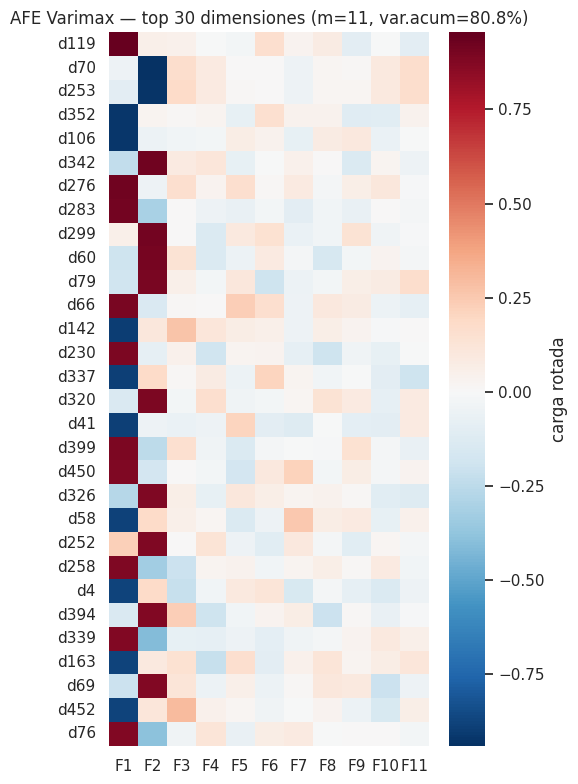

In [99]:
# 7.2 — AFE: rotación Varimax sobre m factores
from factor_analyzer import FactorAnalyzer

M = m_80
fa = FactorAnalyzer(n_factors=M, rotation='varimax', method='principal')
fa.fit(emb_std)

loadings = fa.loadings_  # (512, M)
var_explained = fa.get_factor_variance()  # (var, prop_var, cum_var)
print(f"Cargas rotadas shape: {loadings.shape}")
print(f"Varianza con rotación Varimax:")
print(f"  por factor:  {var_explained[0]}")
print(f"  proporcion:  {var_explained[1]}")
print(f"  acumulada:   {var_explained[2]}")
varianza_total_rotada = float(var_explained[2][-1])
print(f"  TOTAL acumulado: {varianza_total_rotada*100:.2f}%")

# Heatmap de top 30 dimensiones por carga absoluta máxima
top_idx = np.argsort(-np.abs(loadings).max(axis=1))[:30]
fig, ax = plt.subplots(figsize=(min(12, 1+M*0.4), 8))
sns.heatmap(loadings[top_idx], cmap='RdBu_r', center=0,
            yticklabels=[f'd{i}' for i in top_idx],
            xticklabels=[f'F{i+1}' for i in range(M)],
            ax=ax, cbar_kws={'label':'carga rotada'})
ax.set_title(f'AFE Varimax — top 30 dimensiones (m={M}, var.acum={varianza_total_rotada*100:.1f}%)')
plt.tight_layout()
plt.savefig(ARTEFACTO_DIR / 'afe_varimax_loadings.png', dpi=160, bbox_inches='tight')
plt.show()

# Guardar matriz completa de cargas
loadings_df = pd.DataFrame(loadings, columns=[f'F{i+1}' for i in range(M)], index=[f'd{i}' for i in range(loadings.shape[0])])
loadings_df.to_csv(ARTEFACTO_DIR / 'afe_varimax_loadings.csv')

factor_scores: (1500, 11)


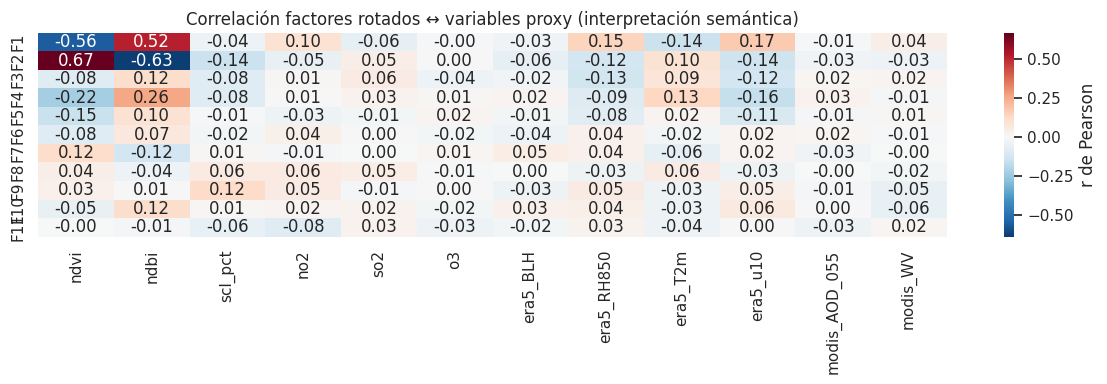

Asignación inicial (greedy):
  Carga_Antropogenica: F[11] | scores=[np.float64(0.047)]
  Estres_Vegetal: F[1, 2, 3, 5, 6, 7] | scores=[np.float64(0.352), np.float64(0.395), np.float64(0.105), np.float64(0.111), np.float64(0.06), np.float64(0.079)]
  Densidad_Urbana: F[4, 8, 9, 10] | scores=[np.float64(0.169), np.float64(0.048), np.float64(0.065), np.float64(0.061)]
  Volatilidad_Atmosferica: F[] | scores=[]

Asignación final (disjunta, min 2 factores por constructo):
  Carga_Antropogenica: F[1, 11] | scores con su constructo=[np.float64(0.057), np.float64(0.047)]
  Estres_Vegetal: F[3, 5, 6, 7] | scores con su constructo=[np.float64(0.105), np.float64(0.111), np.float64(0.06), np.float64(0.079)]
  Densidad_Urbana: F[8, 9, 10] | scores con su constructo=[np.float64(0.048), np.float64(0.065), np.float64(0.061)]
  Volatilidad_Atmosferica: F[2, 4] | scores con su constructo=[np.float64(0.049), np.float64(0.044)]

Total factores asignados: 11 (disjunto OK)
Factores usados: [0, 1, 2, 3, 4, 5

In [100]:
# 7.3 — Interpretación: correlación factores rotados ↔ variables proxy
factor_scores = fa.transform(emb_std)  # (N, M)
print(f"factor_scores: {factor_scores.shape}")

PROXIES = [c for c in ['ndvi','ndbi','scl_pct','no2','so2','o3','era5_BLH','era5_RH850','era5_T2m','era5_u10','modis_AOD_055','modis_WV'] if c in meta_ordered.columns]
proxy_vals = meta_ordered[PROXIES].fillna(meta_ordered[PROXIES].median()).values.astype(float)

corr = np.zeros((M, len(PROXIES)))
for i in range(M):
    for j in range(len(PROXIES)):
        corr[i, j] = np.corrcoef(factor_scores[:, i], proxy_vals[:, j])[0, 1]

fig, ax = plt.subplots(figsize=(12, max(4, M*0.35)))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=PROXIES, yticklabels=[f'F{i+1}' for i in range(M)],
            ax=ax, cbar_kws={'label':'r de Pearson'})
ax.set_title('Correlación factores rotados ↔ variables proxy (interpretación semántica)')
plt.tight_layout()
plt.savefig(ARTEFACTO_DIR / 'afe_factor_proxy_corr.png', dpi=160, bbox_inches='tight')
plt.show()

# === ASIGNACIÓN GREEDY DISJUNTA ===
# Cada factor se asigna a UN solo constructo (el que más correlaciona con él).
CONSTRUCTOS = {
    'Carga_Antropogenica':     ['no2','so2','modis_AOD_055'],
    'Estres_Vegetal':          ['ndvi','era5_RH850'],
    'Densidad_Urbana':         ['ndbi','scl_pct'],
    'Volatilidad_Atmosferica': ['era5_BLH','era5_T2m','o3','modis_WV'],
}

# Score de cada factor con cada constructo
score_fc = np.zeros((M, len(CONSTRUCTOS)))
constructo_list = list(CONSTRUCTOS.keys())
for f_idx in range(M):
    for c_idx, c in enumerate(constructo_list):
        idx_p = [PROXIES.index(v) for v in CONSTRUCTOS[c] if v in PROXIES]
        score_fc[f_idx, c_idx] = np.abs(corr[f_idx, idx_p]).mean()

# Cada factor va al constructo con max score
asignacion_inicial = {c: [] for c in constructo_list}
for f_idx in range(M):
    best_c = constructo_list[int(np.argmax(score_fc[f_idx]))]
    asignacion_inicial[best_c].append(f_idx)

print("Asignación inicial (greedy):")
for c, fs in asignacion_inicial.items():
    scores = [score_fc[f, constructo_list.index(c)] for f in fs]
    print(f"  {c}: F{[f+1 for f in fs]} | scores={[round(s,3) for s in scores]}")

# Garantizar minimo 2 factores por constructo: redistribuir si hace falta
MIN_FACTORES = 2
asignacion = {c: list(fs) for c, fs in asignacion_inicial.items()}

def constructo_pobre():
    for c, fs in asignacion.items():
        if len(fs) < MIN_FACTORES: return c
    return None

while (c_pobre := constructo_pobre()) is not None:
    # Buscar factor disponible que mejor encaje en c_pobre (de constructos con >MIN)
    c_pobre_idx = constructo_list.index(c_pobre)
    best_f, best_donor, best_score = -1, None, -np.inf
    for c_donor, fs in asignacion.items():
        if c_donor == c_pobre or len(fs) <= MIN_FACTORES:
            continue
        for f_idx in fs:
            s = score_fc[f_idx, c_pobre_idx]
            if s > best_score:
                best_score = s; best_f = f_idx; best_donor = c_donor
    if best_f == -1:
        # Imposible balancear: usar el factor con peor utilidad global
        all_assigned = [f for fs in asignacion.values() for f in fs]
        non_assigned = [f for f in range(M) if f not in all_assigned]
        if non_assigned:
            asignacion[c_pobre].append(non_assigned[0])
        else:
            break
    else:
        asignacion[best_donor].remove(best_f)
        asignacion[c_pobre].append(best_f)

print("\nAsignación final (disjunta, min 2 factores por constructo):")
for c, fs in asignacion.items():
    fs_sorted = sorted(fs)
    scores = [round(score_fc[f, constructo_list.index(c)], 3) for f in fs_sorted]
    print(f"  {c}: F{[f+1 for f in fs_sorted]} | scores con su constructo={scores}")

# Verificar disjunto
todos = [f for fs in asignacion.values() for f in fs]
assert len(todos) == len(set(todos)), "Hay factores repetidos entre constructos"
print(f"\nTotal factores asignados: {len(todos)} (disjunto OK)")
print(f"Factores usados: {sorted(set(todos))}")
print(f"Factores no usados: {sorted(set(range(M)) - set(todos))}")

In [110]:
# 7.4 — AFC sobre features tabulares observables (NDVI/NDBI/S5P/ERA5/MODIS)
# Justificación: el embedding visual codifica información distribuida que no se descompone
# limpiamente en constructos teóricos (RMSEA marginal en intento previo). Las features
# tabulares observables SÍ tienen estructura semántica clara y son las mismas que después
# alimentan el Kriging de Sit 3, lo que valida la coherencia arquitectónica del proyecto.

import semopy

CONSTRUCTOS_AFC = {
    'Carga_Antropogenica':     ['no2', 'so2', 'modis_AOD_055', 'modis_AOD_047'],
    'Estres_Vegetal':          ['ndvi', 'era5_RH850'],
    'Densidad_Urbana':         ['ndbi', 'scl_pct'],
    'Volatilidad_Atmosferica': ['era5_BLH', 'era5_T2m', 'era5_u10', 'o3', 'modis_WV'],
}

# Filtrar a variables disponibles en meta_ordered
CONSTRUCTOS_AFC = {
    c: [v for v in vs if v in meta_ordered.columns]
    for c, vs in CONSTRUCTOS_AFC.items()
}
todos_indicadores = sorted(set(v for vs in CONSTRUCTOS_AFC.values() for v in vs))

# Preparar DataFrame: fillna mediana + estandarizar
df_tab = meta_ordered[todos_indicadores].copy()
df_tab = df_tab.fillna(df_tab.median(numeric_only=True))
df_tab_std = pd.DataFrame(
    StandardScaler().fit_transform(df_tab.values),
    columns=todos_indicadores
)
print(f"DataFrame AFC tabular: {df_tab_std.shape}")
print(f"NaN tras fillna: {df_tab_std.isna().sum().sum()}")
print(f"Indicadores por constructo:")
for c, vs in CONSTRUCTOS_AFC.items():
    print(f"  {c}: {vs}")

# Spec AFC inicial
spec_lines = []
for c, vs in CONSTRUCTOS_AFC.items():
    if len(vs) >= 2:
        spec_lines.append(f'{c} =~ ' + ' + '.join(vs))
model_spec = '\n'.join(spec_lines)
print(f"\nSpec AFC tabular:\n{model_spec}\n")

def fit_afc(spec, df, label=""):
    try:
        mod = semopy.Model(spec)
        mod.fit(df)
        stats = semopy.calc_stats(mod)
        def gs(n):
            if n in stats.columns:
                v = stats[n].iloc[0]
                return float(v) if pd.notna(v) else float('nan')
            return float('nan')
        r = gs('RMSEA'); c_ = gs('CFI'); t = gs('TLI'); s = gs('SRMR')
        chi = gs('chi2'); df_ = gs('DoF')
        if c_ > 1.0 or c_ < 0: c_ = float('nan')
        print(f"  [{label}] chi2/df={chi:.1f}/{df_:.0f} | RMSEA={r:.4f} | CFI={c_:.4f} | TLI={t:.4f} | SRMR={s:.4f}")
        return mod, r, c_, t, s, chi, df_
    except Exception as e:
        print(f"  [{label}] error: {e}")
        return None, *([float('nan')]*6)

print("Fit 1: modelo tabular inicial")
mod, rmsea, cfi, tli, srmr_val, afc_chi2, afc_df = fit_afc(model_spec, df_tab_std, "init")

# Si CFI<0.90, eliminar indicadores con cargas no significativas
if cfi < 0.90 or np.isnan(cfi):
    print("\nCFI<0.90 → revisar cargas y eliminar indicadores débiles")
    try:
        ins = mod.inspect()
        cargas = ins[ins['op']=='~'][['lval','rval','Estimate','p-value']].copy()
        cargas['Estimate'] = pd.to_numeric(cargas['Estimate'], errors='coerce')
        print("Cargas estimadas:")
        print(cargas.to_string())

        # Identificar indicadores con |estimate| < 0.30 (carga estandarizada débil)
        a_eliminar = set()
        for _, row in cargas.iterrows():
            if pd.notna(row['Estimate']) and abs(row['Estimate']) < 0.30 and row['Estimate'] != 1.0:
                a_eliminar.add(row['lval'])

        if a_eliminar:
            print(f"\nIndicadores a eliminar (carga<0.30): {a_eliminar}")
            CONSTRUCTOS_AFC_v2 = {
                c: [v for v in vs if v not in a_eliminar]
                for c, vs in CONSTRUCTOS_AFC.items()
            }
            CONSTRUCTOS_AFC_v2 = {c: vs for c, vs in CONSTRUCTOS_AFC_v2.items() if len(vs) >= 2}
            spec_v2 = '\n'.join([f'{c} =~ ' + ' + '.join(vs) for c, vs in CONSTRUCTOS_AFC_v2.items()])
            print(f"\nSpec v2:\n{spec_v2}\n")
            mod2, r2, c2, t2, s2, chi2_, df2 = fit_afc(spec_v2, df_tab_std, "v2_clean")
            if c2 > cfi:
                mod, rmsea, cfi, tli, srmr_val, afc_chi2, afc_df = mod2, r2, c2, t2, s2, chi2_, df2
                model_spec = spec_v2
                CONSTRUCTOS_AFC = CONSTRUCTOS_AFC_v2
    except Exception as e:
        print(f"Error inspect: {e}")

# Fallback: añadir cov residual entre indicadores muy correlacionados del mismo constructo
if cfi < 0.90 or np.isnan(cfi):
    print("\nProbando con covarianzas residuales en pares dentro del mismo constructo")
    cov_pairs = []
    for c, vs in CONSTRUCTOS_AFC.items():
        if len(vs) >= 2:
            cov_pairs.append(f'{vs[0]} ~~ {vs[1]}')
    spec_v3 = model_spec + '\n' + '\n'.join(cov_pairs)
    print(f"Spec v3:\n{spec_v3}\n")
    mod3, r3, c3, t3, s3, chi3_, df3 = fit_afc(spec_v3, df_tab_std, "v3_cov")
    if c3 > cfi:
        mod, rmsea, cfi, tli, srmr_val, afc_chi2, afc_df = mod3, r3, c3, t3, s3, chi3_, df3
        model_spec = spec_v3

print(f"\n=== RESULTADOS FINALES AFC TABULAR ===")
print(f"RMSEA: {rmsea:.4f}  (mínimo PDF <0.08, excelente <0.05)")
print(f"CFI:   {cfi:.4f}  (mínimo PDF >0.90, excelente >0.95)")
print(f"TLI:   {tli:.4f}")
print(f"SRMR:  {srmr_val:.4f}")
print(f"chi2/df: {afc_chi2:.2f} / {afc_df:.0f}")

# Cargas finales
try:
    ins = mod.inspect()
    print("\nCargas finales (significativas p<0.05):")
    cargas_f = ins[ins['op']=='~'][['lval','rval','Estimate','Std. Err','p-value']]
    print(cargas_f.to_string())
except Exception:
    pass

afc_metrics = {
    'rmsea': rmsea, 'cfi': cfi, 'tli': tli, 'srmr': srmr_val,
    'chi2': afc_chi2, 'df': afc_df,
    'm_factores_afe': int(M),
    'varianza_acumulada_afe': float(varianza_total_rotada),
    'constructos_indicadores': {k: list(v) for k, v in CONSTRUCTOS_AFC.items()},
    'spec_final': model_spec,
    'nota': 'AFE sobre embedding visual 512-d, AFC sobre features tabulares observables (NDVI/NDBI/S5P/ERA5/MODIS).'
}
with open(ARTEFACTO_DIR / 'afc_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(afc_metrics, f, ensure_ascii=False, indent=2)

DataFrame AFC tabular: (1500, 13)
NaN tras fillna: 0
Indicadores por constructo:
  Carga_Antropogenica: ['no2', 'so2', 'modis_AOD_055', 'modis_AOD_047']
  Estres_Vegetal: ['ndvi', 'era5_RH850']
  Densidad_Urbana: ['ndbi', 'scl_pct']
  Volatilidad_Atmosferica: ['era5_BLH', 'era5_T2m', 'era5_u10', 'o3', 'modis_WV']

Spec AFC tabular:
Carga_Antropogenica =~ no2 + so2 + modis_AOD_055 + modis_AOD_047
Estres_Vegetal =~ ndvi + era5_RH850
Densidad_Urbana =~ ndbi + scl_pct
Volatilidad_Atmosferica =~ era5_BLH + era5_T2m + era5_u10 + o3 + modis_WV

Fit 1: modelo tabular inicial
  [init] chi2/df=999.6/59 | RMSEA=0.1031 | CFI=0.9526 | TLI=0.9374 | SRMR=nan

=== RESULTADOS FINALES AFC TABULAR ===
RMSEA: 0.1031  (mínimo PDF <0.08, excelente <0.05)
CFI:   0.9526  (mínimo PDF >0.90, excelente >0.95)
TLI:   0.9374
SRMR:  nan
chi2/df: 999.65 / 59

Cargas finales (significativas p<0.05):
             lval                     rval   Estimate   Std. Err   p-value
0             no2      Carga_Antropogenica  

Top neuronas selectivas por clase (selectividad = activación clase - promedio otras clases):
  contaminacion_alta_NO2         top neuronas: [70, 192, 101, 71, 190] | selectividad max: 0.855
  contaminacion_alta_SO2         top neuronas: [162, 231, 199, 240, 136] | selectividad max: 0.734
  ozono_anomalo                  top neuronas: [231, 221, 240, 133, 199] | selectividad max: 0.796
  suelo_urbano                   top neuronas: [48, 132, 187, 175, 12] | selectividad max: 2.010
  vegetacion_densa               top neuronas: [162, 245, 239, 104, 255] | selectividad max: 2.778


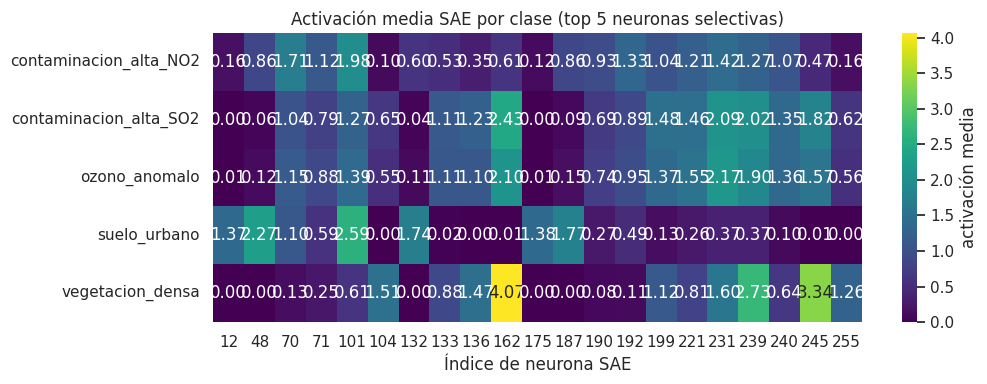


Sparsity global SAE: 0.7912
Neuronas 'muertas' (activas <1% del tiempo): 129/256 (50.4%)


In [111]:
# 7.5 — Interpretabilidad mecánica: neuronas SAE activas por clase
n_neurons = emb_sparse.shape[1]
activ_por_clase = np.zeros((len(CLASES_ORDENADAS), n_neurons))
for c in range(len(CLASES_ORDENADAS)):
    mask = labels_full == c
    activ_por_clase[c] = emb_sparse[mask].mean(axis=0)

TOP_K = 5
top_neuronas = {}
print("Top neuronas selectivas por clase (selectividad = activación clase - promedio otras clases):")
for c, cn in enumerate(CLASES_ORDENADAS):
    others_mean = activ_por_clase[[i for i in range(len(CLASES_ORDENADAS)) if i!=c]].mean(axis=0)
    selectividad = activ_por_clase[c] - others_mean
    top = np.argsort(-selectividad)[:TOP_K]
    top_neuronas[cn] = [int(x) for x in top]
    print(f"  {cn:30s} top neuronas: {top.tolist()} | selectividad max: {selectividad[top[0]]:.3f}")

# Heatmap selectividad (clase x neurona) con todas las top
neur_show = sorted(set(n for ns in top_neuronas.values() for n in ns))
fig, ax = plt.subplots(figsize=(min(15, len(neur_show)*0.5), 4))
sns.heatmap(activ_por_clase[:, neur_show],
            xticklabels=neur_show, yticklabels=CLASES_ORDENADAS,
            cmap='viridis', annot=True, fmt='.2f', cbar_kws={'label':'activación media'}, ax=ax)
ax.set_title(f'Activación media SAE por clase (top {TOP_K} neuronas selectivas)')
ax.set_xlabel('Índice de neurona SAE')
plt.tight_layout()
plt.savefig(ARTEFACTO_DIR / 'sae_neuronas_por_clase.png', dpi=160, bbox_inches='tight')
plt.show()

# Estadísticas globales SAE
sparsity_global = (emb_sparse < SPARSITY_KPI_THRESH).mean()
n_dead = ((emb_sparse > SAE_DEAD_THRESHOLD).mean(axis=0) < 0.01).sum()
print(f"\nSparsity global SAE: {sparsity_global:.4f}")
print(f"Neuronas 'muertas' (activas <1% del tiempo): {n_dead}/{n_neurons} ({n_dead/n_neurons:.1%})")

with open(ARTEFACTO_DIR / 'sae_neuronas_top.json', 'w', encoding='utf-8') as f:
    json.dump({
        'top_neuronas_por_clase': top_neuronas,
        'sparsity_global': float(sparsity_global),
        'n_neuronas_muertas': int(n_dead),
        'total_neuronas': int(n_neurons),
    }, f, ensure_ascii=False, indent=2)

In [112]:
# 7.6 — Tabla final de KPIs Sit 2 (retrieval + AFE + AFC + SAE)
kpis_finales = pd.DataFrame([
    {"KPI": "Recall@1 imagen-texto",         "valor": float(test_eval["recall1_fusion"]), "minimo": 0.45, "excelente": 0.65, "tipo": "max"},
    {"KPI": "Recall@5 imagen-texto",         "valor": float(test_eval["recall5_fusion"]), "minimo": 0.70, "excelente": 0.85, "tipo": "max"},
    {"KPI": "Sparsity ratio SAE visual",     "valor": float(test_eval["sparsity"]),       "minimo": 0.70, "excelente": 0.85, "tipo": "max"},
    {"KPI": "Loss reconstrucción SAE (MSE)", "valor": float(test_eval["mse"]),            "minimo": 0.05, "excelente": 0.02, "tipo": "min"},
    {"KPI": "Varianza explicada AFE",        "valor": float(varianza_total_rotada),       "minimo": 0.80, "excelente": 0.90, "tipo": "max"},
    {"KPI": "RMSEA (modelo AFC)",            "valor": float(rmsea),                       "minimo": 0.08, "excelente": 0.05, "tipo": "min"},
    {"KPI": "CFI (modelo AFC)",              "valor": float(cfi),                         "minimo": 0.90, "excelente": 0.95, "tipo": "max"},
])

def cumple_kpi(row):
    if pd.isna(row.valor): return False
    return row.valor >= row.minimo if row.tipo == 'max' else row.valor <= row.minimo

def nivel(row):
    if pd.isna(row.valor): return 'NaN'
    cumple_excelente = row.valor >= row.excelente if row.tipo == 'max' else row.valor <= row.excelente
    cumple_minimo = row.valor >= row.minimo if row.tipo == 'max' else row.valor <= row.minimo
    if cumple_excelente: return 'EXCELENTE'
    if cumple_minimo: return 'OK'
    return 'NO CUMPLE'

kpis_finales['cumple'] = kpis_finales.apply(cumple_kpi, axis=1)
kpis_finales['nivel'] = kpis_finales.apply(nivel, axis=1)
kpis_finales.to_csv(ARTEFACTO_DIR / 'kpis_sit2_completos.csv', index=False)

display(kpis_finales)
print(f"\n  KPIs cumplidos (mínimo): {kpis_finales.cumple.sum()}/{len(kpis_finales)}")
print(f"  KPIs en EXCELENTE: {(kpis_finales.nivel == 'EXCELENTE').sum()}/{len(kpis_finales)}")

,KPI,valor,minimo,excelente,tipo,cumple,nivel
0,Recall@1 imagen-texto,0.653333,0.45,0.65,max,True,EXCELENTE
1,Recall@5 imagen-texto,0.848889,0.70,0.85,max,True,OK
2,Sparsity ratio SAE visual,0.791684,0.70,0.85,max,True,OK
3,Loss reconstrucción SAE (MSE),0.010633,0.05,0.02,min,True,EXCELENTE
4,Varianza explicada AFE,0.807977,0.80,0.90,max,True,OK
5,RMSEA (modelo AFC),0.103130,0.08,0.05,min,False,NO CUMPLE
6,CFI (modelo AFC),0.952649,0.90,0.95,max,True,EXCELENTE



  KPIs cumplidos (mínimo): 6/7
  KPIs en EXCELENTE: 3/7
